# Phase 1: Data Integration & Preprocessing
## Fezf2 Multi-Omics Analysis - scRNA-seq Data

**Goal**: Load all scRNA-seq samples, perform comprehensive QC with **deep learning-based doublet detection**, and integrate data using scverse ecosystem

**Dataset**: GSE153164 - Di Bella et al. 2021
- Wild-type developmental time course: E10, E11.5, E12.5, E13.5, E14.5, E15.5, E16, E17.5, E18.5, P1 (2 replicates), P4
- Fezf2 heterozygous: E13, E15, P1 (Female), P1 (Male)
- Fezf2 knockout: E13, E15, P1

**Tools**: scanpy, anndata, scvi-tools (Solo for doublet detection, scVI for integration), harmonypy

**Key QC Steps**:
1. Standard QC metrics (genes, counts, mitochondrial %)
2. **Deep learning doublet detection using Solo (scvi-tools)**
3. MAD-based adaptive thresholding
4. Batch integration comparison (Harmony vs scVI)

**References**:
- Bernstein et al. 2020 "Solo: Doublet Identification in Single-Cell RNA-Seq via Semi-Supervised Deep Learning"
- Luecken et al. 2022 "Benchmarking atlas-level data integration in single-cell genomics"

## Step 1: Environment Setup & Import Libraries

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import gc
from pathlib import Path
import warnings
import yaml
warnings.filterwarnings('ignore')

In [3]:
# Memory management - critical for large datasets
import scipy.sparse as sp

def print_memory_usage():
    """Print current memory usage."""
    import psutil
    process = psutil.Process()
    mem_gb = process.memory_info().rss / 1e9
    print(f"Current memory usage: {mem_gb:.2f} GB")

print_memory_usage()

Current memory usage: 0.28 GB


In [4]:
# Scverse ecosystem
import scanpy as sc
import anndata as ad
import muon as mu

# Deep learning integration and doublet detection
import scvi
from scvi.model import SOLO  # Deep learning doublet detection

# Print versions
print(f"scanpy version: {sc.__version__}")
print(f"anndata version: {ad.__version__}")
print(f"muon version: {mu.__version__}")
print(f"scvi-tools version: {scvi.__version__}")

ImportError: cannot import name 'SOLO' from 'scvi.model' (/opt/miniconda3/envs/scverse/lib/python3.11/site-packages/scvi/model/__init__.py)

In [6]:
# Integration tools
import harmonypy
print(f"harmonypy version: {harmonypy.__version__}")

harmonypy version: 0.0.10


In [7]:
# Print versions
print(f"scanpy version: {sc.__version__}")
print(f"anndata version: {ad.__version__}")
print(f"muon version: {mu.__version__}")

scanpy version: 1.11.5
anndata version: 0.12.7
muon version: 0.1.7


In [5]:
# Set plotting parameters for publication-quality figures
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=150, facecolor='white', frameon=False)

# Updated paths for restructured project
RESULTS_DIR = Path('../results/preprocessing')
FIGURES_DIR = RESULTS_DIR / 'figures'
QC_DIR = Path('../results/qc')
DATA_DIR = Path('../data/raw/scRNAseq')
PROCESSED_DIR = Path('../data/processed')

# Create directories if they don't exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
QC_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sc.settings.figdir = FIGURES_DIR
sc.settings.n_jobs = -1  # Use all available cores for parallel processing

# Publication-ready figure settings
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts for PDF
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

print(f"Results directory: {RESULTS_DIR.absolute()}")
print(f"Data directory: {DATA_DIR.absolute()}")

Results directory: /Users/jubayer/Projects/single-cell/fezf2-multiomics/notebooks/../results/preprocessing
Data directory: /Users/jubayer/Projects/single-cell/fezf2-multiomics/notebooks/../data/raw/scRNAseq


In [8]:
# Random seed for reproducibility
np.random.seed(42)

## Step 2: Define Sample Metadata

We'll create a comprehensive metadata table for all 23 scRNA-seq samples.

In [9]:
# Define sample metadata
sample_metadata = pd.DataFrame([
    # Wild-type time course
    {'gsm_id': 'GSM5277843', 'filename': 'GSM5277843_E10_v1_filtered_feature_bc_matrix.h5', 
     'timepoint': 'E10', 'genotype': 'WT', 'sex': 'NA', 'replicate': 1, 'batch': 'batch2'},
    {'gsm_id': 'GSM4635072', 'filename': 'GSM4635072_E11_5_filtered_gene_bc_matrices_h5.h5', 
     'timepoint': 'E11.5', 'genotype': 'WT', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635073', 'filename': 'GSM4635073_E12_5_filtered_gene_bc_matrices_h5.h5', 
     'timepoint': 'E12.5', 'genotype': 'WT', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635074', 'filename': 'GSM4635074_E13_5_filtered_gene_bc_matrices_h5.h5', 
     'timepoint': 'E13.5', 'genotype': 'WT', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635075', 'filename': 'GSM4635075_E14_5_filtered_gene_bc_matrices_h5.h5', 
     'timepoint': 'E14.5', 'genotype': 'WT', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635076', 'filename': 'GSM4635076_E15_5_S1_filtered_gene_bc_matrices_h5.h5', 
     'timepoint': 'E15.5', 'genotype': 'WT', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635077', 'filename': 'GSM4635077_E16_filtered_gene_bc_matrices_h5.h5', 
     'timepoint': 'E16', 'genotype': 'WT', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM5277844', 'filename': 'GSM5277844_E17_5_filtered_feature_bc_matrix.h5', 
     'timepoint': 'E17.5', 'genotype': 'WT', 'sex': 'NA', 'replicate': 1, 'batch': 'batch2'},
    {'gsm_id': 'GSM4635078', 'filename': 'GSM4635078_E18_5_S1_filtered_gene_bc_matrices_h5.h5', 
     'timepoint': 'E18.5', 'genotype': 'WT', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635079', 'filename': 'GSM4635079_E18_S3_filtered_gene_bc_matrices_h5.h5', 
     'timepoint': 'E18.5', 'genotype': 'WT', 'sex': 'NA', 'replicate': 2, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635080', 'filename': 'GSM4635080_P1_S1_filtered_gene_bc_matrices_h5.h5', 
     'timepoint': 'P1', 'genotype': 'WT', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635081', 'filename': 'GSM4635081_P1_S2_filtered_gene_bc_matrices_h5.h5', 
     'timepoint': 'P1', 'genotype': 'WT', 'sex': 'NA', 'replicate': 2, 'batch': 'batch1'},
    {'gsm_id': 'GSM5277845', 'filename': 'GSM5277845_P4_filtered_feature_bc_matrix.h5', 
     'timepoint': 'P4', 'genotype': 'WT', 'sex': 'NA', 'replicate': 1, 'batch': 'batch2'},
    
    # Fezf2 heterozygous samples
    {'gsm_id': 'GSM4635088', 'filename': 'GSM4635088_Fezf2het_E13_filtered_feature_bc_matrix.h5', 
     'timepoint': 'E13', 'genotype': 'Het', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635082', 'filename': 'GSM4635082_Fezf2Het_E15_filtered_feature_bc_matrix.h5', 
     'timepoint': 'E15', 'genotype': 'Het', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635083', 'filename': 'GSM4635083_Fezf2Het_P1F_filtered_feature_bc_matrix.h5', 
     'timepoint': 'P1', 'genotype': 'Het', 'sex': 'Female', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635084', 'filename': 'GSM4635084_Fezf2Het_P1M_filtered_feature_bc_matrix.h5', 
     'timepoint': 'P1', 'genotype': 'Het', 'sex': 'Male', 'replicate': 1, 'batch': 'batch1'},
    
    # Fezf2 knockout samples
    {'gsm_id': 'GSM4635085', 'filename': 'GSM4635085_Fezf2KO_E13_filtered_feature_bc_matrix.h5', 
     'timepoint': 'E13', 'genotype': 'KO', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635086', 'filename': 'GSM4635086_Fezf2KO_E15_filtered_feature_bc_matrix.h5', 
     'timepoint': 'E15', 'genotype': 'KO', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
    {'gsm_id': 'GSM4635087', 'filename': 'GSM4635087_Fezf2KO_P1_filtered_feature_bc_matrix.h5', 
     'timepoint': 'P1', 'genotype': 'KO', 'sex': 'NA', 'replicate': 1, 'batch': 'batch1'},
])

# Create sample_id combining timepoint and genotype
sample_metadata['sample_id'] = sample_metadata.apply(
    lambda x: f"{x['timepoint']}_{x['genotype']}" + (f"_{x['sex']}" if x['sex'] != 'NA' else '') + 
              (f"_rep{x['replicate']}" if x['replicate'] > 1 or (x['timepoint'] == 'P1' and x['genotype'] == 'WT') else ''),
    axis=1
)
sample_metadata

,gsm_id,filename,timepoint,genotype,sex,replicate,batch,sample_id
0,GSM5277843,GSM5277843_E10_v1_filtered_feature_bc_matrix.h5,E10,WT,NA,1,batch2,E10_WT
1,GSM4635072,GSM4635072_E11_5_filtered_gene_bc_matrices_h5.h5,E11.5,WT,NA,1,batch1,E11.5_WT
2,GSM4635073,GSM4635073_E12_5_filtered_gene_bc_matrices_h5.h5,E12.5,WT,NA,1,batch1,E12.5_WT
3,GSM4635074,GSM4635074_E13_5_filtered_gene_bc_matrices_h5.h5,E13.5,WT,NA,1,batch1,E13.5_WT
4,GSM4635075,GSM4635075_E14_5_filtered_gene_bc_matrices_h5.h5,E14.5,WT,NA,1,batch1,E14.5_WT
5,GSM4635076,GSM4635076_E15_5_S1_filtered_gene_bc_matrices_...,E15.5,WT,NA,1,batch1,E15.5_WT
6,GSM4635077,GSM4635077_E16_filtered_gene_bc_matrices_h5.h5,E16,WT,NA,1,batch1,E16_WT
7,GSM5277844,GSM5277844_E17_5_filtered_feature_bc_matrix.h5,E17.5,WT,NA,1,batch2,E17.5_WT
8,GSM4635078,GSM4635078_E18_5_S1_filtered_gene_bc_matrices_...,E18.5,WT,NA,1,batch1,E18.5_WT
9,GSM4635079,GSM4635079_E18_S3_filtered_gene_bc_matrices_h5.h5,E18.5,WT,NA,2,batch1,E18.5_WT_rep2


In [10]:
len(sample_metadata)

20

In [11]:
sample_metadata['genotype'].value_counts()

genotype
WT     13
Het     4
KO      3
Name: count, dtype: int64

In [12]:
sample_metadata['timepoint'].value_counts().sort_index()

timepoint
E10      1
E11.5    1
E12.5    1
E13      2
E13.5    1
E14.5    1
E15      2
E15.5    1
E16      1
E17.5    1
E18.5    2
P1       5
P4       1
Name: count, dtype: int64

---
## Step 3: Load Single Sample for Initial Exploration

Let's start by loading one sample to understand the data structure and set QC parameters.

In [13]:
# Test loading a single sample to verify paths
test_file = DATA_DIR / "GSM4635072_E11_5_filtered_gene_bc_matrices_h5.h5"
if test_file.exists():
    adata_test = sc.read_10x_h5(str(test_file), gex_only=True)
    print(f"\nTest sample loaded successfully!")
    print(f"Shape: {adata_test.shape[0]} cells × {adata_test.shape[1]} genes")
    # Clean up test data
    del adata_test
    gc.collect()
else:
    print(f"Warning: Test file not found at {test_file}")
    print("Available files in data directory:")
    if DATA_DIR.exists():
        for f in list(DATA_DIR.glob("*.h5"))[:5]:
            print(f"  - {f.name}")

reading ../data/raw/scRNAseq/GSM4635072_E11_5_filtered_gene_bc_matrices_h5.h5
 (0:00:00)

Test sample loaded successfully!
Shape: 2757 cells × 27998 genes


---
## Step 4: Load All Samples

Now we'll load all 23 scRNA-seq samples and add metadata to each.

In [14]:
def load_sample(row, data_dir):
    """
    Load a single 10x h5 file and add metadata.
    Memory-efficient: ensures sparse matrix format.
    """
    # Create the full path to the file
    filepath = data_dir / row['filename']
    
    # Verify file existence to prevent crashes
    if not filepath.exists():
        print(f"Error: File not found for {row['sample_id']} at {filepath}")
        return None
    
    try:
        # Load the h5 file
        adata = sc.read_10x_h5(str(filepath), gex_only=True)
        
        # MEMORY OPTIMIZATION: Ensure sparse matrix format
        if not sp.issparse(adata.X):
            adata.X = sp.csr_matrix(adata.X)
        
        # Ensure gene names are unique for downstream merging
        adata.var_names_make_unique()
        
        # Map metadata from the dataframe to the AnnData object
        adata.obs['sample_id'] = str(row['sample_id'])
        adata.obs['gsm_id'] = str(row['gsm_id'])
        adata.obs['timepoint'] = str(row['timepoint'])
        adata.obs['genotype'] = str(row['genotype'])
        adata.obs['sex'] = str(row['sex'])
        adata.obs['replicate'] = str(row['replicate'])
        adata.obs['batch'] = str(row['batch'])
        
        n_cells = adata.shape[0]
        print(f"Loaded {row['sample_id']}: {n_cells:,} cells")
        return adata
        
    except Exception as e:
        print(f"Failed to load {row['sample_id']}: {e}")
        return None

# Execution block with memory monitoring
print(f"Processing samples from: {DATA_DIR.absolute()}")
print_memory_usage()

adatas = []
for idx, row in sample_metadata.iterrows():
    adata = load_sample(row, DATA_DIR)
    if adata is not None:
        adatas.append(adata)
    
    # Periodic garbage collection for memory efficiency
    if (idx + 1) % 5 == 0:
        gc.collect()
        print_memory_usage()

print(f"\nFinished: {len(adatas)} samples loaded")
print_memory_usage()

Processing samples from: /Users/jubayer/Projects/single-cell/fezf2-multiomics/notebooks/../data/raw/scRNAseq
Current memory usage: 0.96 GB
reading ../data/raw/scRNAseq/GSM5277843_E10_v1_filtered_feature_bc_matrix.h5
 (0:00:00)
Loaded E10_WT: 1,078 cells
reading ../data/raw/scRNAseq/GSM4635072_E11_5_filtered_gene_bc_matrices_h5.h5
 (0:00:00)
Loaded E11.5_WT: 2,757 cells
reading ../data/raw/scRNAseq/GSM4635073_E12_5_filtered_gene_bc_matrices_h5.h5
 (0:00:00)
Loaded E12.5_WT: 8,015 cells
reading ../data/raw/scRNAseq/GSM4635074_E13_5_filtered_gene_bc_matrices_h5.h5
 (0:00:00)
Loaded E13.5_WT: 6,415 cells
reading ../data/raw/scRNAseq/GSM4635075_E14_5_filtered_gene_bc_matrices_h5.h5
 (0:00:00)
Loaded E14.5_WT: 3,485 cells
Current memory usage: 1.46 GB
reading ../data/raw/scRNAseq/GSM4635076_E15_5_S1_filtered_gene_bc_matrices_h5.h5
 (0:00:00)
Loaded E15.5_WT: 10,891 cells
reading ../data/raw/scRNAseq/GSM4635077_E16_filtered_gene_bc_matrices_h5.h5
 (0:00:00)
Loaded E16_WT: 5,332 cells
reading 

In [16]:
# check data 
adata.obs

,sample_id,gsm_id,timepoint,genotype,sex,replicate,batch
AAACCCAAGGCTCACC-1,P1_KO,GSM4635087,P1,KO,NA,1,batch1
AAACCCACAATCGCCG-1,P1_KO,GSM4635087,P1,KO,NA,1,batch1
AAACCCACAGGTGTGA-1,P1_KO,GSM4635087,P1,KO,NA,1,batch1
AAACCCACAGTGGCTC-1,P1_KO,GSM4635087,P1,KO,NA,1,batch1
AAACCCAGTCGTAATC-1,P1_KO,GSM4635087,P1,KO,NA,1,batch1
...,...,...,...,...,...,...,...
TTTGTTGCAATACAGA-1,P1_KO,GSM4635087,P1,KO,NA,1,batch1
TTTGTTGGTACCAATC-1,P1_KO,GSM4635087,P1,KO,NA,1,batch1
TTTGTTGGTATGATCC-1,P1_KO,GSM4635087,P1,KO,NA,1,batch1
TTTGTTGGTGATTAGA-1,P1_KO,GSM4635087,P1,KO,NA,1,batch1


## Step 5: Concatenate All Samples

Merge all samples into a single AnnData object for integrated analysis.

In [17]:
# Concatenate all samples with memory-efficient settings
print("Concatenating all samples...")
print_memory_usage()

adata_all = ad.concat(
    adatas,
    join='outer',  # Keep all genes (union)
    merge='unique',  # Make cell barcodes unique
    label='sample_id',
    keys=[adata.obs['sample_id'].iloc[0] for adata in adatas],
    index_unique='_'
)

# MEMORY OPTIMIZATION: Ensure sparse format after concatenation
if not sp.issparse(adata_all.X):
    print("Converting to sparse matrix format...")
    adata_all.X = sp.csr_matrix(adata_all.X)

# Clear individual sample data to free memory
del adatas
gc.collect()

print(f"\nCombined dataset: {adata_all.shape[0]:,} cells × {adata_all.shape[1]:,} genes")
print(f"Matrix format: {type(adata_all.X).__name__}")
print(f"Memory usage (data): {adata_all.X.data.nbytes / 1e9:.2f} GB")
print_memory_usage()

# Display summary
print("\nCells per sample:")
print(adata_all.obs['sample_id'].value_counts())

Concatenating all samples...
Current memory usage: 4.85 GB

Combined dataset: 128,746 cells × 27,998 genes
Matrix format: csr_matrix
Memory usage (data): 1.24 GB
Current memory usage: 4.70 GB

Cells per sample:
sample_id
E18.5_WT_rep2    11500
E15.5_WT         10891
E15_Het          10085
E15_KO            9788
E17.5_WT          8982
P1_KO             8386
E12.5_WT          8015
P1_WT_rep1        6552
P4_WT             6480
E13.5_WT          6415
E18.5_WT          6237
E16_WT            5332
P1_Het_Male       5288
P1_WT_rep2        4691
P1_Het_Female     4655
E13_Het           4460
E13_KO            3669
E14.5_WT          3485
E11.5_WT          2757
E10_WT            1078
Name: count, dtype: int64


In [19]:
# check adata_all 
adata_all.obs

,sample_id,gsm_id,timepoint,genotype,sex,replicate,batch
AAACCTGCAGACAAGC-1_E10_WT,E10_WT,GSM5277843,E10,WT,NA,1,batch2
AAACCTGCAGAGCCAA-1_E10_WT,E10_WT,GSM5277843,E10,WT,NA,1,batch2
AAACGGGTCAGTTAGC-1_E10_WT,E10_WT,GSM5277843,E10,WT,NA,1,batch2
AAAGATGCAAAGGAAG-1_E10_WT,E10_WT,GSM5277843,E10,WT,NA,1,batch2
AAAGATGGTTCTCATT-1_E10_WT,E10_WT,GSM5277843,E10,WT,NA,1,batch2
...,...,...,...,...,...,...,...
TTTGTTGCAATACAGA-1_P1_KO,P1_KO,GSM4635087,P1,KO,NA,1,batch1
TTTGTTGGTACCAATC-1_P1_KO,P1_KO,GSM4635087,P1,KO,NA,1,batch1
TTTGTTGGTATGATCC-1_P1_KO,P1_KO,GSM4635087,P1,KO,NA,1,batch1
TTTGTTGGTGATTAGA-1_P1_KO,P1_KO,GSM4635087,P1,KO,NA,1,batch1


---
## Step 6: Calculate QC Metrics

Calculate quality control metrics:
- Number of genes per cell
- Total UMI counts per cell
- Mitochondrial gene percentage
- Ribosomal gene percentage

In [20]:
# Identify mitochondrial genes (genes starting with 'mt-' or 'Mt-')
adata_all.var['mt'] = adata_all.var_names.str.startswith(('mt-', 'Mt-'))
print(f"Mitochondrial genes found: {adata_all.var['mt'].sum()}")

# Identify ribosomal genes (genes starting with 'Rpl' or 'Rps')
adata_all.var['ribo'] = adata_all.var_names.str.match('^Rp[sl]')
print(f"Ribosomal genes found: {adata_all.var['ribo'].sum()}")

# Calculate QC metrics
print("\nCalculating QC metrics...")
sc.pp.calculate_qc_metrics(
    adata_all,
    qc_vars=['mt', 'ribo'],
    percent_top=None,
    log1p=False,
    inplace=True
)

print("\nQC metrics added to .obs:")
print(adata_all.obs.columns.tolist())

Mitochondrial genes found: 13
Ribosomal genes found: 113

Calculating QC metrics...

QC metrics added to .obs:
['sample_id', 'gsm_id', 'timepoint', 'genotype', 'sex', 'replicate', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo']


In [21]:
# Display QC statistics
qc_metrics = adata_all.obs[[
    'n_genes_by_counts',
    'total_counts',
    'pct_counts_mt',
    'pct_counts_ribo'
]]

qc_metrics

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo
AAACCTGCAGACAAGC-1_E10_WT,1432,2492.0,2.126806,12.800963
AAACCTGCAGAGCCAA-1_E10_WT,1416,2514.0,2.108194,12.490056
AAACGGGTCAGTTAGC-1_E10_WT,4424,15744.0,1.467226,12.627032
AAAGATGCAAAGGAAG-1_E10_WT,2858,7429.0,1.655674,11.253197
AAAGATGGTTCTCATT-1_E10_WT,1651,3026.0,2.015863,12.095175
...,...,...,...,...
TTTGTTGCAATACAGA-1_P1_KO,3249,8003.0,8.146945,9.608897
TTTGTTGGTACCAATC-1_P1_KO,1595,2773.0,7.536963,6.635413
TTTGTTGGTATGATCC-1_P1_KO,2585,6195.0,6.182405,11.993543
TTTGTTGGTGATTAGA-1_P1_KO,2141,5285.0,5.430464,14.285715


In [22]:
qc_metrics.describe()

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo
count,128746.000000,128746.000000,128746.000000,128746.000000
mean,2416.501196,7301.374512,5.160143,15.805728
std,1179.650163,6972.980469,4.047752,4.771587
min,25.000000,500.000000,0.000000,0.070538
25%,1614.000000,3489.000000,3.049805,12.822753
50%,2177.000000,5315.000000,4.190792,15.378671
75%,2953.000000,8578.000000,6.394522,18.515732
max,10348.000000,250845.000000,96.037300,67.212570


---
## Step 7: Visualize QC Metrics

Create comprehensive QC visualizations to guide filtering thresholds.

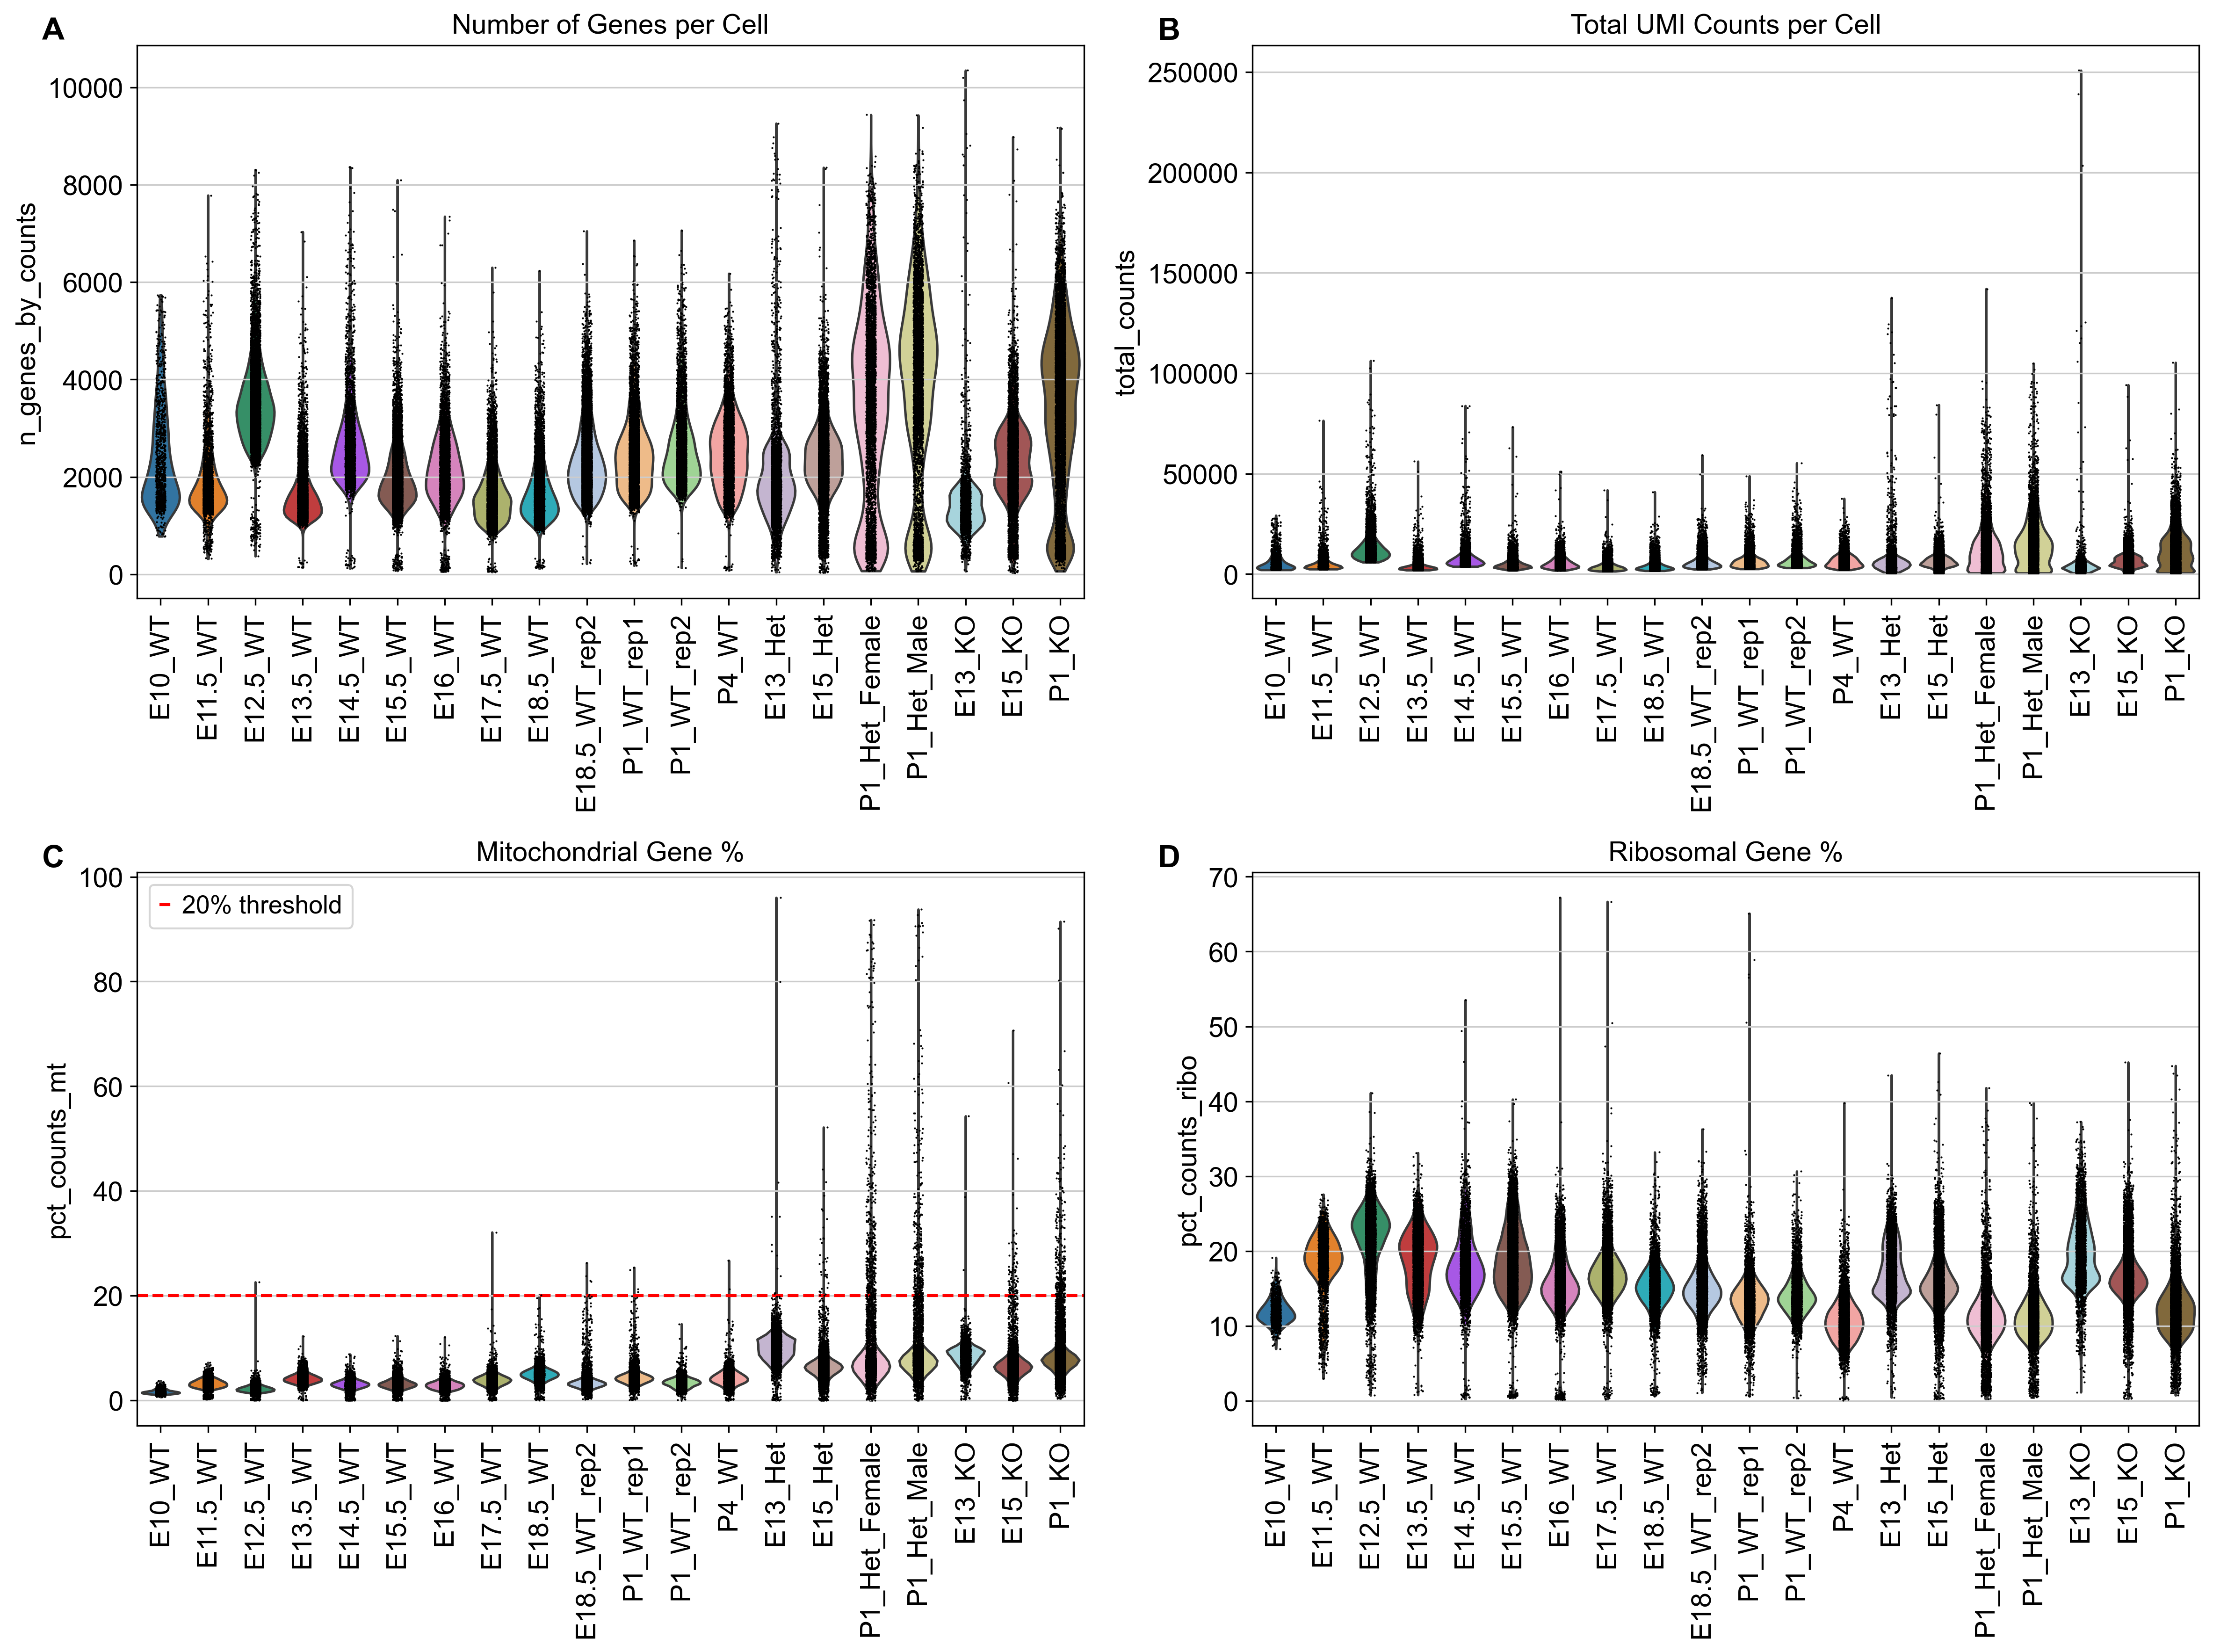

In [23]:
# QC violin plots by sample
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Number of genes
sc.pl.violin(adata_all, 'n_genes_by_counts', groupby='sample_id',
             rotation=90, ax=axes[0,0], show=False)
axes[0,0].set_title('Number of Genes per Cell')
axes[0,0].text(-0.1, 1.05, 'A', transform=axes[0,0].transAxes,
               fontsize=16, fontweight='bold', va='top')

# Total counts
sc.pl.violin(adata_all, 'total_counts', groupby='sample_id',
             rotation=90, ax=axes[0,1], show=False)
axes[0,1].set_title('Total UMI Counts per Cell')
axes[0,1].text(-0.1, 1.05, 'B', transform=axes[0,1].transAxes,
               fontsize=16, fontweight='bold', va='top')

# Mitochondrial percentage
sc.pl.violin(adata_all, 'pct_counts_mt', groupby='sample_id',
             rotation=90, ax=axes[1,0], show=False)
axes[1,0].set_title('Mitochondrial Gene %')
axes[1,0].axhline(y=20, color='red', linestyle='--', label='20% threshold')
axes[1,0].legend()
axes[1,0].text(-0.1, 1.05, 'C', transform=axes[1,0].transAxes,
               fontsize=16, fontweight='bold', va='top')

# Ribosomal percentage
sc.pl.violin(adata_all, 'pct_counts_ribo', groupby='sample_id',
             rotation=90, ax=axes[1,1], show=False)
axes[1,1].set_title('Ribosomal Gene %')
axes[1,1].text(-0.1, 1.05, 'D', transform=axes[1,1].transAxes,
               fontsize=16, fontweight='bold', va='top')

plt.tight_layout()
# plt.savefig(FIGURES_DIR / '01_qc_violin_by_sample.pdf', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / '01_qc_violin_by_sample.png', bbox_inches='tight', dpi=150)
plt.show()

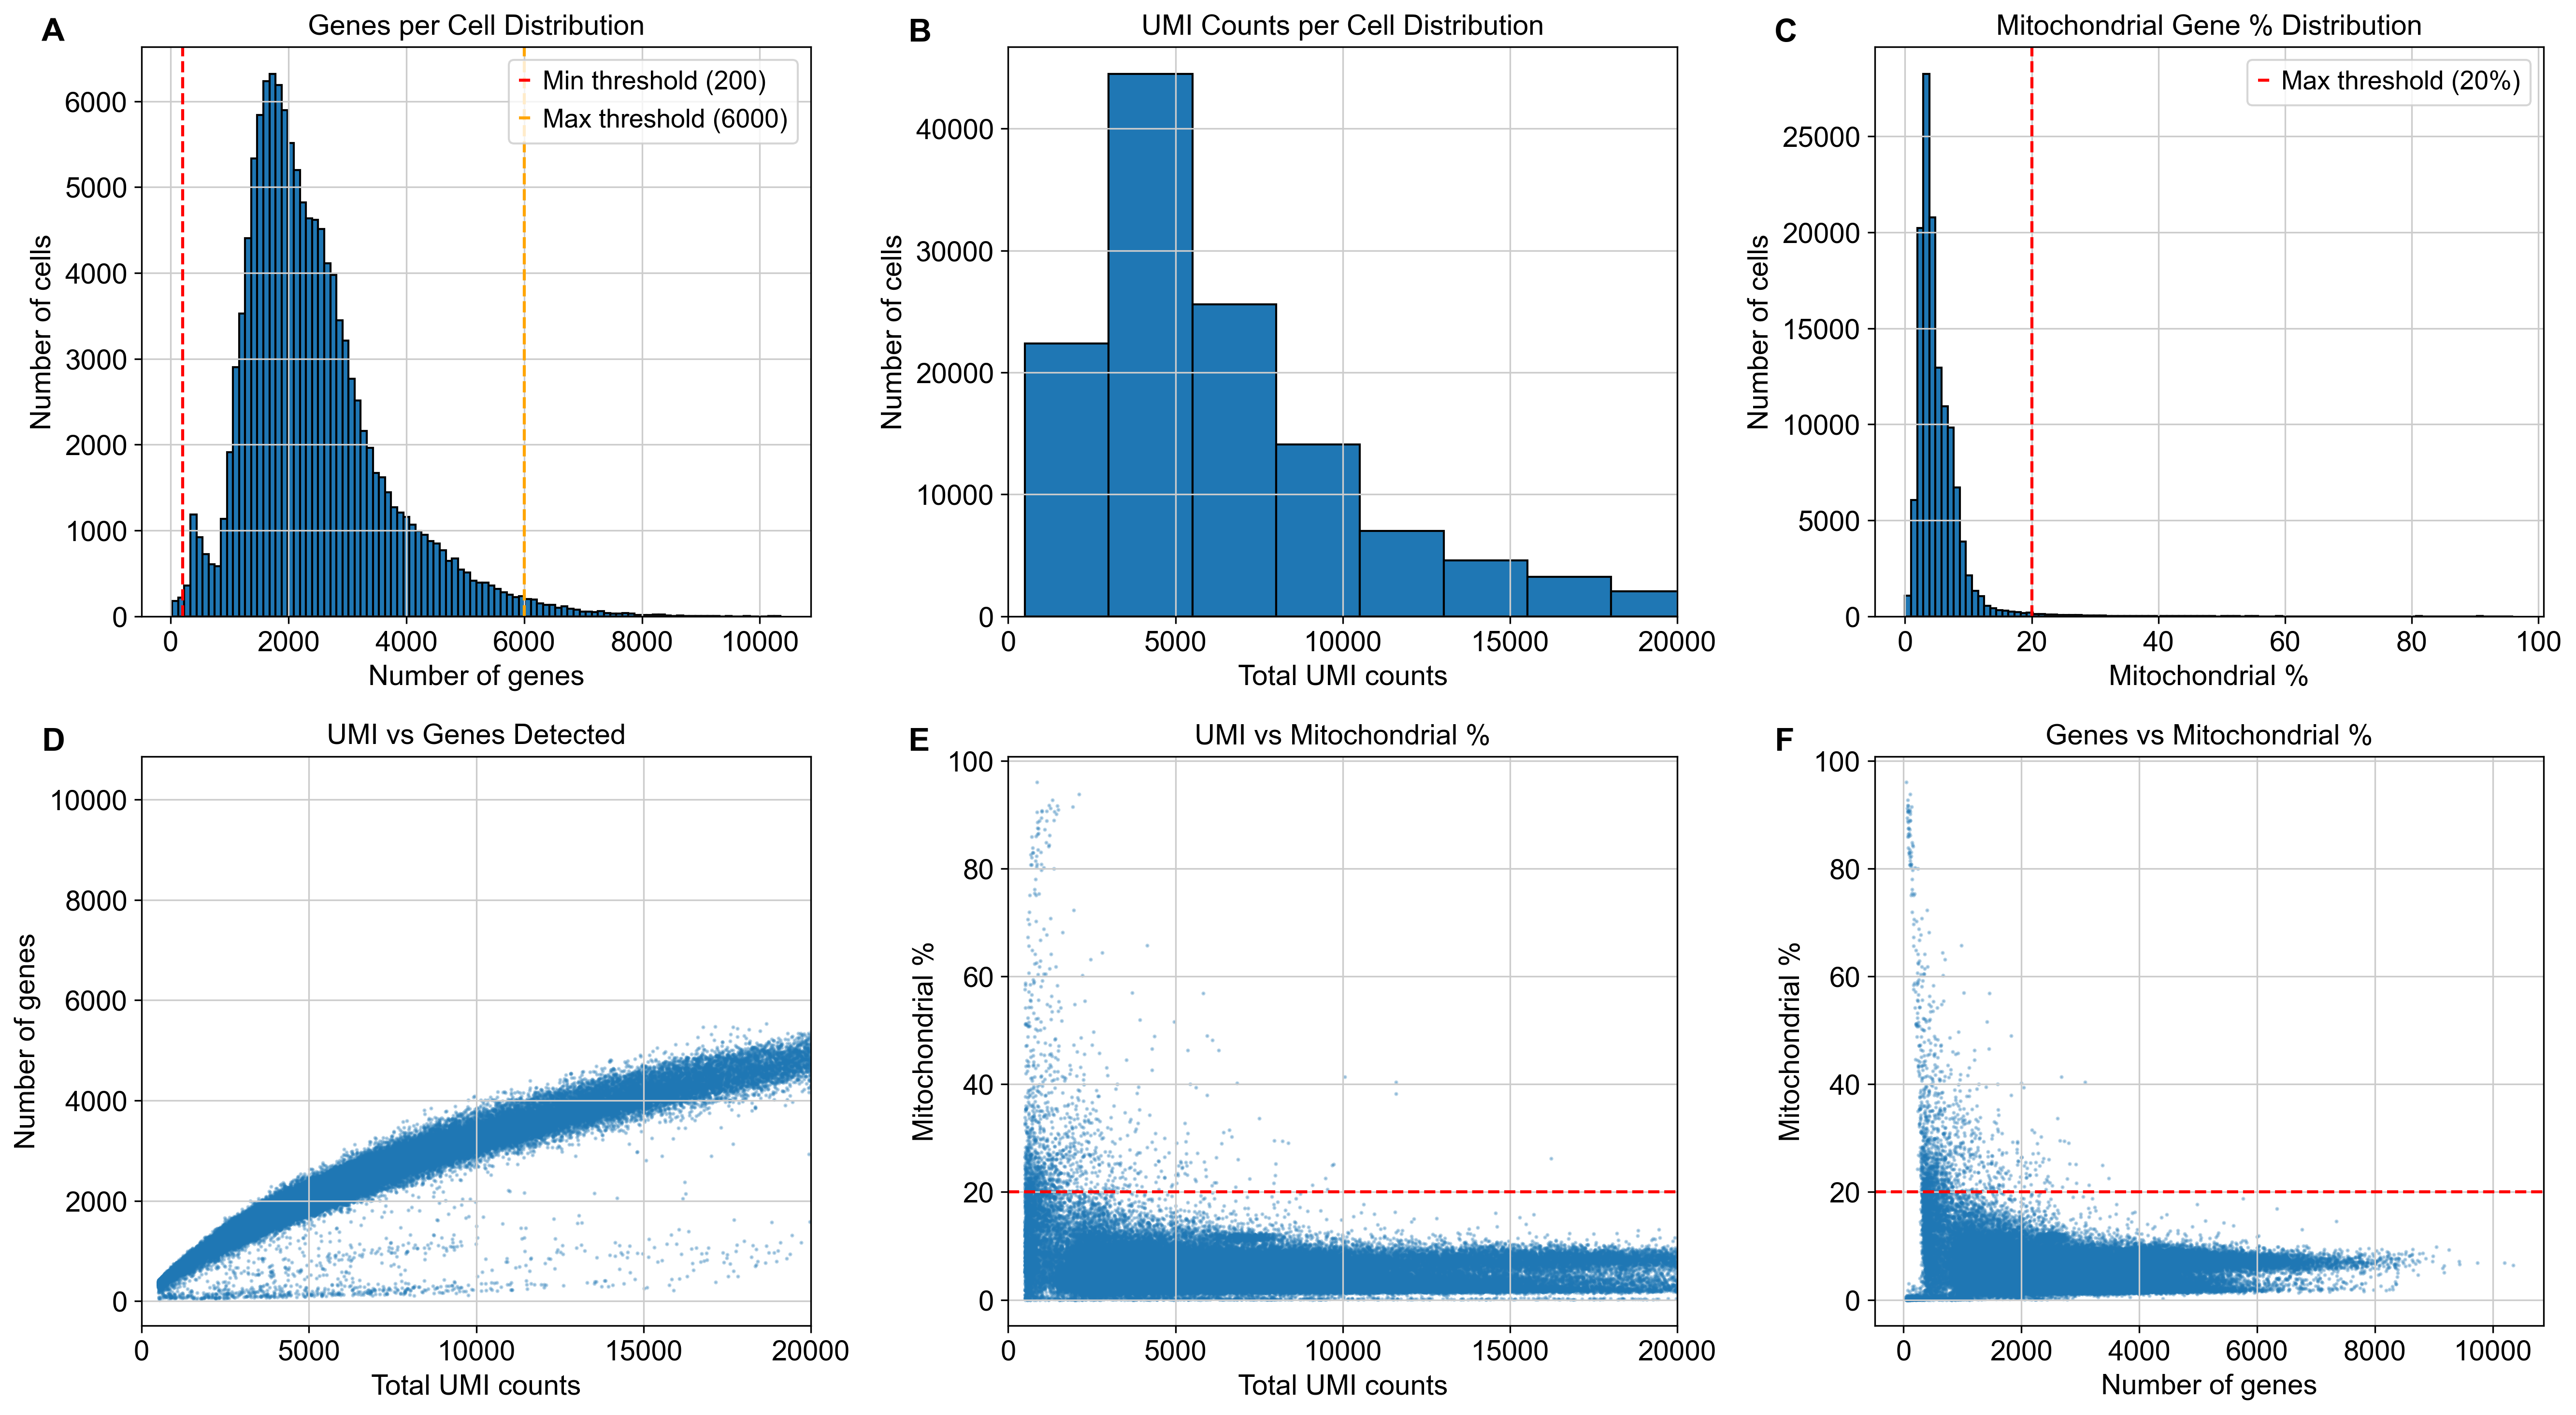

In [25]:
# Overall QC distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Genes per cell histogram
axes[0,0].hist(adata_all.obs['n_genes_by_counts'], bins=100, edgecolor='black')
axes[0,0].set_xlabel('Number of genes')
axes[0,0].set_ylabel('Number of cells')
axes[0,0].set_title('Genes per Cell Distribution')
axes[0,0].axvline(x=200, color='red', linestyle='--', label='Min threshold (200)')
axes[0,0].axvline(x=6000, color='orange', linestyle='--', label='Max threshold (6000)')
axes[0,0].legend()
axes[0,0].text(-0.15, 1.05, 'A', transform=axes[0,0].transAxes,
               fontsize=16, fontweight='bold', va='top')

# UMI counts histogram
axes[0,1].hist(adata_all.obs['total_counts'], bins=100, edgecolor='black')
axes[0,1].set_xlabel('Total UMI counts')
axes[0,1].set_ylabel('Number of cells')
axes[0,1].set_title('UMI Counts per Cell Distribution')
axes[0,1].set_xlim(0, 20000)
axes[0,1].text(-0.15, 1.05, 'B', transform=axes[0,1].transAxes,
               fontsize=16, fontweight='bold', va='top')

# Mitochondrial % histogram
axes[0,2].hist(adata_all.obs['pct_counts_mt'], bins=100, edgecolor='black')
axes[0,2].set_xlabel('Mitochondrial %')
axes[0,2].set_ylabel('Number of cells')
axes[0,2].set_title('Mitochondrial Gene % Distribution')
axes[0,2].axvline(x=20, color='red', linestyle='--', label='Max threshold (20%)')
axes[0,2].legend()
axes[0,2].text(-0.15, 1.05, 'C', transform=axes[0,2].transAxes,
               fontsize=16, fontweight='bold', va='top')

# Scatter: UMI vs Genes
axes[1,0].scatter(adata_all.obs['total_counts'], adata_all.obs['n_genes_by_counts'],
                  s=1, alpha=0.3, rasterized=True)
axes[1,0].set_xlabel('Total UMI counts')
axes[1,0].set_ylabel('Number of genes')
axes[1,0].set_title('UMI vs Genes Detected')
axes[1,0].set_xlim(0, 20000)
axes[1,0].text(-0.15, 1.05, 'D', transform=axes[1,0].transAxes,
               fontsize=16, fontweight='bold', va='top')

# Scatter: UMI vs MT%
axes[1,1].scatter(adata_all.obs['total_counts'], adata_all.obs['pct_counts_mt'],
                  s=1, alpha=0.3, rasterized=True)
axes[1,1].set_xlabel('Total UMI counts')
axes[1,1].set_ylabel('Mitochondrial %')
axes[1,1].set_title('UMI vs Mitochondrial %')
axes[1,1].axhline(y=20, color='red', linestyle='--')
axes[1,1].set_xlim(0, 20000)
axes[1,1].text(-0.15, 1.05, 'E', transform=axes[1,1].transAxes,
               fontsize=16, fontweight='bold', va='top')

# Scatter: Genes vs MT%
axes[1,2].scatter(adata_all.obs['n_genes_by_counts'], adata_all.obs['pct_counts_mt'],
                  s=1, alpha=0.3, rasterized=True)
axes[1,2].set_xlabel('Number of genes')
axes[1,2].set_ylabel('Mitochondrial %')
axes[1,2].set_title('Genes vs Mitochondrial %')
axes[1,2].axhline(y=20, color='red', linestyle='--')
axes[1,2].text(-0.15, 1.05, 'F', transform=axes[1,2].transAxes,
               fontsize=16, fontweight='bold', va='top')

plt.tight_layout()
# plt.savefig(FIGURES_DIR / '02_qc_distributions.pdf', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / '02_qc_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

NameError: name 'doublet_summary' is not defined

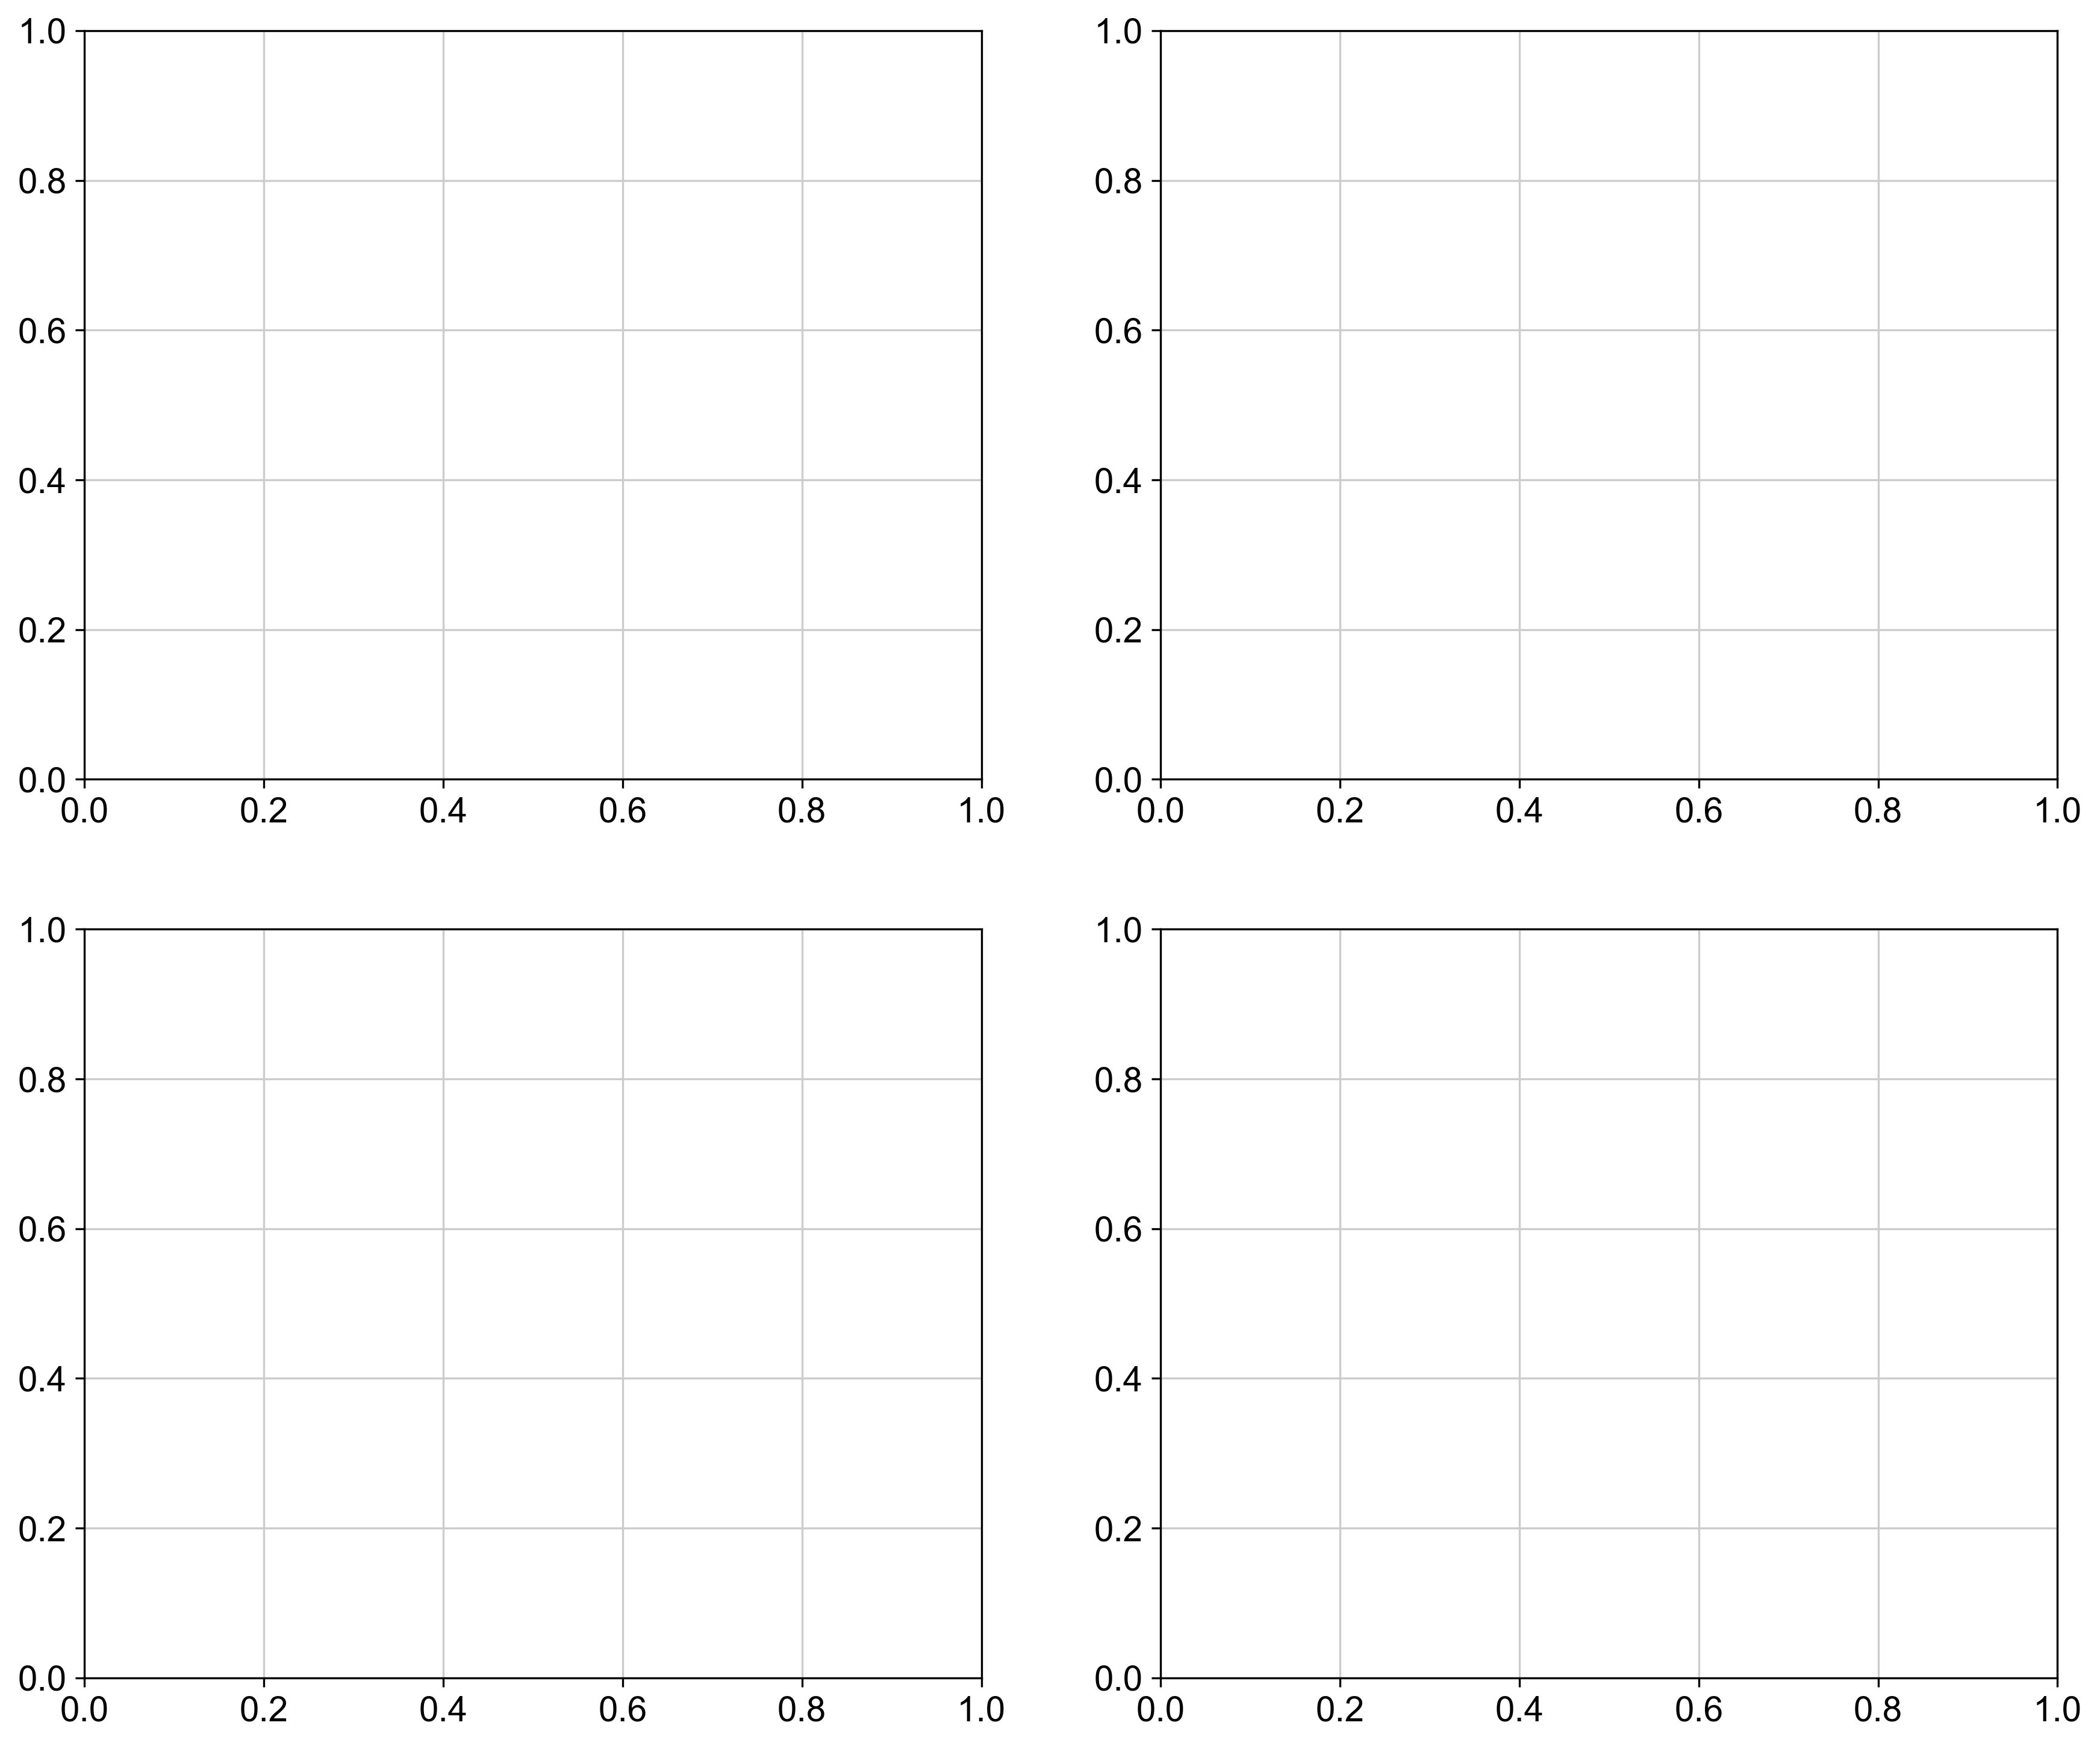

In [26]:
# Visualize doublet detection results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Panel A: Doublet rate per sample
ax = axes[0, 0]
doublet_summary_sorted = doublet_summary.sort_values('doublet_rate', ascending=True)
bars = ax.barh(doublet_summary_sorted['sample'], doublet_summary_sorted['doublet_rate'], 
               color='coral', edgecolor='black')
ax.set_xlabel('Doublet Rate (%)', fontsize=12)
ax.set_ylabel('Sample', fontsize=12)
ax.set_title('Doublet Rate per Sample', fontsize=14, fontweight='bold')
ax.axvline(x=8, color='red', linestyle='--', label='8% threshold')
ax.legend(loc='lower right')
ax.text(-0.15, 1.05, 'A', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')

# Panel B: Doublet score distribution
ax = axes[0, 1]
ax.hist(adata_all.obs['doublet_score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(x=0.5, color='red', linestyle='--', label='Classification threshold')
ax.set_xlabel('Doublet Score', fontsize=12)
ax.set_ylabel('Number of Cells', fontsize=12)
ax.set_title('Doublet Score Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.text(-0.15, 1.05, 'B', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')

# Panel C: Doublet score vs gene count
ax = axes[1, 0]
scatter = ax.scatter(
    adata_all.obs['n_genes_by_counts'],
    adata_all.obs['doublet_score'],
    c=adata_all.obs['is_doublet'].astype(int),
    cmap='coolwarm',
    s=1, alpha=0.3, rasterized=True
)
ax.set_xlabel('Number of Genes', fontsize=12)
ax.set_ylabel('Doublet Score', fontsize=12)
ax.set_title('Doublet Score vs Gene Count', fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.text(-0.15, 1.05, 'C', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')

# Panel D: Doublet score vs UMI count
ax = axes[1, 1]
scatter = ax.scatter(
    adata_all.obs['total_counts'],
    adata_all.obs['doublet_score'],
    c=adata_all.obs['is_doublet'].astype(int),
    cmap='coolwarm',
    s=1, alpha=0.3, rasterized=True
)
ax.set_xlabel('Total UMI Counts', fontsize=12)
ax.set_ylabel('Doublet Score', fontsize=12)
ax.set_title('Doublet Score vs UMI Count', fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlim(0, 30000)
ax.text(-0.15, 1.05, 'D', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top')

# Add colorbar for scatter plots
cbar = plt.colorbar(scatter, ax=axes[1, :], shrink=0.5, aspect=20, pad=0.02)
cbar.set_label('Predicted Doublet', fontsize=12)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Singlet', 'Doublet'])

plt.tight_layout()
# plt.savefig(FIGURES_DIR / '02b_doublet_detection.pdf', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / '02b_doublet_detection.png', bbox_inches='tight', dpi=150)
plt.show()

In [24]:
# Print summary statistics
print("\n" + "=" * 60)
print("DOUBLET DETECTION RESULTS")
print("=" * 60)
print(f"Total cells analyzed: {adata_all.n_obs:,}")
print(f"Doublets detected: {adata_all.obs['is_doublet'].sum():,}")
print(f"Overall doublet rate: {adata_all.obs['is_doublet'].mean() * 100:.2f}%")
print(f"\nDoublet rate range across samples:")
print(f"  Min: {doublet_summary['doublet_rate'].min():.1f}%")
print(f"  Max: {doublet_summary['doublet_rate'].max():.1f}%")
print(f"  Mean: {doublet_summary['doublet_rate'].mean():.1f}%")
print("=" * 60)


DOUBLET DETECTION RESULTS
Total cells analyzed: 128,746


KeyError: 'is_doublet'

In [ ]:
# Run Solo doublet detection
# This step is computationally intensive but critical for publication-quality analysis
# Expected runtime: 2-5 minutes per sample depending on cell count and GPU availability

print("Starting doublet detection...")
print_memory_usage()

# Store raw counts before any normalization for doublet detection
adata_all.layers['counts'] = adata_all.X.copy()

# Run doublet detection on raw counts
adata_all, doublet_summary = run_solo_doublet_detection(
    adata_all, 
    sample_key='sample_id',
    n_top_genes=2000
)

# Save doublet summary
doublet_summary.to_csv(QC_DIR / 'doublet_detection_summary.csv', index=False)

print("\nDoublet summary saved to: results/qc/doublet_detection_summary.csv")
print_memory_usage()

In [ ]:
def run_solo_doublet_detection(adata, sample_key='sample_id', n_top_genes=2000):
    """
    Run Solo (scvi-tools) doublet detection per sample.
    
    Memory-efficient implementation that processes samples sequentially
    and uses sparse matrices throughout.
    
    Parameters
    ----------
    adata : AnnData
        Combined AnnData object with all samples
    sample_key : str
        Column in .obs containing sample identifiers
    n_top_genes : int
        Number of highly variable genes to use for model training
        
    Returns
    -------
    AnnData with doublet_score and is_doublet columns added to .obs
    """
    from scvi.model import SCVI, SOLO
    
    samples = adata.obs[sample_key].unique()
    n_samples = len(samples)
    
    # Initialize arrays to store results
    all_doublet_scores = np.zeros(adata.n_obs)
    all_is_doublet = np.zeros(adata.n_obs, dtype=bool)
    
    print(f"Running Solo doublet detection on {n_samples} samples...")
    print("=" * 60)
    
    doublet_stats = []
    
    for i, sample in enumerate(samples):
        print(f"\n[{i+1}/{n_samples}] Processing {sample}...")
        
        # Subset to this sample
        mask = adata.obs[sample_key] == sample
        adata_sample = adata[mask].copy()
        n_cells = adata_sample.n_obs
        
        print(f"  Cells: {n_cells:,}")
        
        # Skip small samples
        if n_cells < 100:
            print(f"  Skipping (too few cells)")
            continue
        
        try:
            # Prepare sample for scVI
            # Select HVGs for this sample
            sc.pp.highly_variable_genes(
                adata_sample,
                n_top_genes=min(n_top_genes, adata_sample.n_vars),
                flavor='seurat_v3',
                subset=True
            )
            
            # Setup scVI
            SCVI.setup_anndata(adata_sample)
            
            # Train a lightweight scVI model
            vae = SCVI(
                adata_sample,
                n_layers=1,  # Lighter model for speed
                n_latent=10,
                gene_likelihood='nb'
            )
            
            # Train with early stopping
            vae.train(
                max_epochs=100,
                early_stopping=True,
                early_stopping_patience=5,
                train_size=0.9,
                batch_size=128,
                plan_kwargs={'lr': 1e-3},
                check_val_every_n_epoch=5
            )
            
            # Create and train Solo model
            solo = SOLO.from_scvi_model(vae)
            solo.train(
                max_epochs=100,
                early_stopping=True,
                early_stopping_patience=5,
                train_size=0.9,
                batch_size=128
            )
            
            # Get doublet predictions
            predictions = solo.predict()
            
            # Store results (predictions are 'singlet' vs 'doublet')
            doublet_scores = predictions['doublet'].values
            is_doublet = predictions['prediction'].values == 'doublet'
            
            # Map back to full dataset
            sample_indices = np.where(mask)[0]
            all_doublet_scores[sample_indices] = doublet_scores
            all_is_doublet[sample_indices] = is_doublet
            
            # Calculate statistics
            doublet_rate = is_doublet.sum() / len(is_doublet) * 100
            doublet_stats.append({
                'sample': sample,
                'n_cells': n_cells,
                'n_doublets': is_doublet.sum(),
                'doublet_rate': doublet_rate
            })
            
            print(f"  Doublets detected: {is_doublet.sum()} ({doublet_rate:.1f}%)")
            
            # Clean up
            del adata_sample, vae, solo, predictions
            gc.collect()
            
        except Exception as e:
            print(f"  Error: {e}")
            print(f"  Skipping sample")
            continue
    
    # Add results to original adata
    adata.obs['doublet_score'] = all_doublet_scores
    adata.obs['is_doublet'] = all_is_doublet
    
    # Create summary DataFrame
    doublet_summary = pd.DataFrame(doublet_stats)
    
    print("\n" + "=" * 60)
    print("DOUBLET DETECTION SUMMARY")
    print("=" * 60)
    print(f"Total doublets: {all_is_doublet.sum():,} / {adata.n_obs:,} cells")
    print(f"Overall doublet rate: {all_is_doublet.sum() / adata.n_obs * 100:.2f}%")
    
    return adata, doublet_summary

print("Solo doublet detection function defined.")

---
## Step 7b: Deep Learning Doublet Detection with Solo

**Doublet detection is critical for publication-quality single-cell analysis.**

Doublets are artificial cells created when two cells are captured in the same droplet. They can:
- Create false cell types
- Confound differential expression
- Distort trajectory analysis

We use **Solo** (Bernstein et al., 2020) from scvi-tools for doublet detection because:
1. **Deep learning approach**: Uses variational autoencoder architecture
2. **Semi-supervised**: Learns from simulated doublets to classify real ones
3. **Per-sample detection**: Accounts for sample-specific characteristics
4. **Probabilistic scores**: Provides uncertainty estimates

**Expected doublet rate**: ~4-8% per sample (10x Genomics typical rate)

**Reference**: Bernstein NJ et al. "Solo: Doublet Identification in Single-Cell RNA-Seq via Semi-Supervised Deep Learning" Cell Systems 2020

---
## Step 8: Apply Quality Control Filters

Based on QC visualizations, apply filtering thresholds:
- **Min genes per cell**: 200 (remove low-quality cells)
- **Max genes per cell**: 6000 (remove potential doublets)
- **Max mitochondrial %**: 20% (remove dying cells)
- **Min cells per gene**: 3 (remove rarely expressed genes)

In [ ]:
# Store raw counts before filtering
print("Storing raw counts in .layers['counts']...")
adata_all.layers['counts'] = adata_all.X.copy()

# Print pre-filtering stats
print(f"\nBefore filtering:")
print(f"  Cells: {adata_all.n_obs:,}")
print(f"  Genes: {adata_all.n_vars:,}")

# Apply cell filters
print("\nApplying QC filters...")

# Filter cells based on:
# - Min 200 genes per cell
# - Max 6000 genes per cell (doublet removal)
# - Max 20% mitochondrial genes
sc.pp.filter_cells(adata_all, min_genes=200)
adata_all = adata_all[adata_all.obs['n_genes_by_counts'] < 6000, :].copy()
adata_all = adata_all[adata_all.obs['pct_counts_mt'] < 20, :].copy()

# Filter genes (min 3 cells)
sc.pp.filter_genes(adata_all, min_cells=3)

# Print post-filtering stats
print(f"\nAfter filtering:")
print(f"  Cells: {adata_all.n_obs:,} ({adata_all.n_obs / len(adatas[0].obs) * 100:.1f}% retained)")
print(f"  Genes: {adata_all.n_vars:,}")

# Show cells retained per sample
print("\nCells retained per sample:")
print(adata_all.obs['sample_id'].value_counts().sort_index())

---
## Step 9: Normalize and Log-Transform

Apply standard normalization:
1. Normalize to 10,000 counts per cell
2. Log-transform (log1p)

In [ ]:
# Normalize to 10,000 counts per cell
print("Normalizing to 10,000 counts per cell...")
sc.pp.normalize_total(adata_all, target_sum=1e4)

# Log transform
print("Log-transforming (log1p)...")
sc.pp.log1p(adata_all)

# Store normalized data
adata_all.layers['log1p_norm'] = adata_all.X.copy()

print("\nNormalization complete!")
print(f"Data stored in .layers['log1p_norm']")
print(f"Raw counts preserved in .layers['counts']")

---
## Step 10: Identify Highly Variable Genes

Select features for downstream analysis using highly variable gene (HVG) selection.

In [ ]:
# Identify highly variable genes
print("Identifying highly variable genes...")
sc.pp.highly_variable_genes(
    adata_all,
    n_top_genes=3000,
    batch_key='sample_id',  # Account for batch effects
    flavor='seurat_v3',
    subset=False  # Keep all genes, just mark HVGs
)

print(f"\nHighly variable genes identified: {adata_all.var['highly_variable'].sum()}")

In [ ]:
# Plot highly variable genes
fig = sc.pl.highly_variable_genes(adata_all, show=False)

# Get the current figure and axes
if isinstance(fig, plt.Figure):
    axes = fig.get_axes()
else:
    fig = plt.gcf()
    axes = fig.get_axes()

# Enhance the plot for publication
for ax in axes:
    # Increase font sizes
    ax.tick_params(labelsize=12)
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    if ax.get_title():
        ax.set_title(ax.get_title(), fontsize=16)

    # Improve legend if present
    legend = ax.get_legend()
    if legend:
        legend.get_frame().set_edgecolor('black')
        legend.get_frame().set_linewidth(1.0)
        legend.get_frame().set_facecolor('white')
        legend.get_frame().set_alpha(1.0)
        for text in legend.get_texts():
            text.set_fontsize(12)

# Add panel labels
if len(axes) >= 1:
    axes[0].text(-0.1, 1.05, 'A', transform=axes[0].transAxes,
                 fontsize=16, fontweight='bold', va='top')
if len(axes) >= 2:
    axes[1].text(-0.1, 1.05, 'B', transform=axes[1].transAxes,
                 fontsize=16, fontweight='bold', va='top')

# Adjust layout and increase figure size if needed
fig.set_size_inches(12, 5)
plt.tight_layout()

plt.savefig('../results/phase1_preprocessing/figures/03_highly_variable_genes.pdf', bbox_inches='tight')
plt.savefig('../results/phase1_preprocessing/figures/03_highly_variable_genes.png', bbox_inches='tight')
plt.show()

---
## Step 11: Save Preprocessed Data (Checkpoint)

Save the preprocessed but unintegrated data.

In [ ]:
# Save preprocessed data
output_file = '../results/phase1_preprocessing/adata_preprocessed.h5ad'
print(f"Saving preprocessed data to {output_file}...")

adata_all.write_h5ad(output_file, compression='gzip')
 
print(f"\nSaved successfully!")
print(f"File size: {Path(output_file).stat().st_size / 1e9:.2f} GB")

---
## Step 12: Initial Dimensionality Reduction (Before Integration)

Let's visualize the data before integration to see batch effects.

In [ ]:
adata_all = sc.read_h5ad("../results/phase1_preprocessing/adata_preprocessed.h5ad")

In [ ]:
adata_all

In [ ]:
# Scale data for PCA (using HVGs only)
print("Scaling highly variable genes...")
sc.pp.scale(adata_all, max_value=10)

# Run PCA
print("Running PCA...")
sc.tl.pca(adata_all, n_comps=50, use_highly_variable=True, svd_solver='arpack')

In [ ]:
# Plot PCA variance ratio
sc.pl.pca_variance_ratio(adata_all, n_pcs=50, log=True, show=False)

# Get the current figure and axes
fig = plt.gcf()
ax = plt.gca()

# Enhance the plot for publication
ax.tick_params(labelsize=12, width=1.5)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
ax.set_ylabel(ax.get_ylabel(), fontsize=14)
if ax.get_title():
    ax.set_title(ax.get_title(), fontsize=16)

# Enhance spines
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Improve legend if present
legend = ax.get_legend()
if legend:
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_linewidth(1.0)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(1.0)
    for text in legend.get_texts():
        text.set_fontsize(12)

# Adjust figure size for better clarity
fig.set_size_inches(12,8)
plt.tight_layout()

plt.savefig('../results/phase1_preprocessing/figures/04_pca_variance_ratio.pdf', bbox_inches='tight')
plt.savefig('../results/phase1_preprocessing/figures/04_pca_variance_ratio.png', bbox_inches='tight')
plt.show()

In [ ]:
# Compute neighbors and UMAP (before integration)
print("Computing neighbor graph...")
sc.pp.neighbors(adata_all, n_neighbors=15, n_pcs=30)

print("Computing UMAP...")
sc.tl.umap(adata_all)

# Store unintegrated UMAP
adata_all.obsm['X_umap_unintegrated'] = adata_all.obsm['X_umap'].copy()

print("UMAP complete!")

In [ ]:
# Visualize UMAP before integration
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# By sample
sc.pl.umap(adata_all, color='sample_id', ax=axes[0,0], show=False, legend_fontsize=8)
axes[0,0].set_title('Before Integration - by Sample', fontsize=14, fontweight='bold')
axes[0,0].text(-0.1, 1.05, 'A', transform=axes[0,0].transAxes,
               fontsize=16, fontweight='bold', va='top')

# By genotype
sc.pl.umap(adata_all, color='genotype', ax=axes[0,1], show=False, legend_fontsize=8)
axes[0,1].set_title('Before Integration - by Genotype', fontsize=14, fontweight='bold')
axes[0,1].text(-0.1, 1.05, 'B', transform=axes[0,1].transAxes,
               fontsize=16, fontweight='bold', va='top')

# By timepoint
sc.pl.umap(adata_all, color='timepoint', ax=axes[1,0], show=False, legend_fontsize=8)
axes[1,0].set_title('Before Integration - by Timepoint', fontsize=14, fontweight='bold')
axes[1,0].text(-0.1, 1.05, 'C', transform=axes[1,0].transAxes,
               fontsize=16, fontweight='bold', va='top')

# By batch
sc.pl.umap(adata_all, color='batch', ax=axes[1,1], show=False, legend_fontsize=8)
axes[1,1].set_title('Before Integration - by Batch', fontsize=14, fontweight='bold')
axes[1,1].text(-0.1, 1.05, 'D', transform=axes[1,1].transAxes,
               fontsize=16, fontweight='bold', va='top')

# Enhance axis labels for all subplots
for ax in axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=12, fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('../results/phase1_preprocessing/figures/05_umap_before_integration.pdf', bbox_inches='tight')
plt.savefig('../results/phase1_preprocessing/figures/05_umap_before_integration.png', bbox_inches='tight')
plt.show()

---
## Step 13: Batch Integration with Harmony

Use Harmony to integrate samples and remove batch effects while preserving biological variation.

In [ ]:
# Run Harmony integration
try:
    import scanpy.external as sce
    
    print("Running Harmony integration...")
    print("This may take 10-20 minutes...\n")
    
    sce.pp.harmony_integrate(
        adata_all,
        key='sample_id',  # Integrate by sample
        basis='X_pca',
        adjusted_basis='X_pca_harmony',
        max_iter_harmony=20,
        verbose=True
    )
    
    print("\nHarmony integration complete!")
    print("Integrated embeddings stored in .obsm['X_pca_harmony']")
    
except ImportError:
    print("ERROR: harmonypy not installed.")
    print("Install with: pip install harmonypy")
    print("\nSkipping integration for now...")

---
## Step 14: UMAP on Integrated Data

Recompute neighbors and UMAP using Harmony-integrated embeddings.

In [ ]:
# Check if Harmony integration was successful
if 'X_pca_harmony' in adata_all.obsm:
    print("Computing neighbors on Harmony embeddings...")
    sc.pp.neighbors(adata_all, n_neighbors=15, n_pcs=30, use_rep='X_pca_harmony')
    
    print("Computing UMAP on integrated data...")
    sc.tl.umap(adata_all)
    
    print("\nIntegrated UMAP complete!")
else:
    print("Harmony integration not found. Using unintegrated data.")

In [ ]:
# Visualize UMAP after integration
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# By sample
sc.pl.umap(adata_all, color='sample_id', ax=axes[0,0], show=False, legend_fontsize=8)
axes[0,0].set_title('After Integration - by Sample', fontsize=14, fontweight='bold')
axes[0,0].text(-0.1, 1.05, 'A', transform=axes[0,0].transAxes,
               fontsize=16, fontweight='bold', va='top')

# By genotype
sc.pl.umap(adata_all, color='genotype', ax=axes[0,1], show=False, legend_fontsize=8)
axes[0,1].set_title('After Integration - by Genotype', fontsize=14, fontweight='bold')
axes[0,1].text(-0.1, 1.05, 'B', transform=axes[0,1].transAxes,
               fontsize=16, fontweight='bold', va='top')

# By timepoint
sc.pl.umap(adata_all, color='timepoint', ax=axes[0,2], show=False, legend_fontsize=8)
axes[0,2].set_title('After Integration - by Timepoint', fontsize=14, fontweight='bold')
axes[0,2].text(-0.1, 1.05, 'C', transform=axes[0,2].transAxes,
               fontsize=16, fontweight='bold', va='top')

# By batch
sc.pl.umap(adata_all, color='batch', ax=axes[1,0], show=False, legend_fontsize=8)
axes[1,0].set_title('After Integration - by Batch', fontsize=14, fontweight='bold')
axes[1,0].text(-0.1, 1.05, 'D', transform=axes[1,0].transAxes,
               fontsize=16, fontweight='bold', va='top')

# By number of genes (QC metric)
sc.pl.umap(adata_all, color='n_genes_by_counts', ax=axes[1,1], show=False, cmap='viridis')
axes[1,1].set_title('After Integration - Gene Count', fontsize=14, fontweight='bold')
axes[1,1].text(-0.1, 1.05, 'E', transform=axes[1,1].transAxes,
               fontsize=16, fontweight='bold', va='top')

# By mitochondrial percentage
sc.pl.umap(adata_all, color='pct_counts_mt', ax=axes[1,2], show=False, cmap='viridis')
axes[1,2].set_title('After Integration - MT %', fontsize=14, fontweight='bold')
axes[1,2].text(-0.1, 1.05, 'F', transform=axes[1,2].transAxes,
               fontsize=16, fontweight='bold', va='top')

# Enhance axis labels for all subplots
for ax in axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=12, fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('../results/phase1_preprocessing/figures/06_umap_after_integration.pdf', bbox_inches='tight')
plt.savefig('../results/phase1_preprocessing/figures/06_umap_after_integration.png', bbox_inches='tight')
plt.show()

---
## Step 14b: Deep Learning Integration with scVI

Use scVI (single-cell Variational Inference) for deep learning-based batch integration.
scVI uses a variational autoencoder to learn a latent representation that removes batch effects while preserving biological variation.

**Advantages of scVI:**
- Probabilistic model that handles noise and dropout
- Scales well to large datasets
- Provides uncertainty estimates
- Can integrate multiple data modalities

**We will compare scVI with Harmony for the paper.**

In [ ]:
# Import scVI for deep learning-based integration
import scvi
print(f"scvi-tools version: {scvi.__version__}")

# Reload preprocessed data (to start fresh for scVI - it needs raw counts)
print("\nLoading preprocessed data for scVI...")
adata_scvi = sc.read_h5ad('../results/phase1_preprocessing/adata_preprocessed.h5ad')
print(f"Loaded: {adata_scvi.n_obs:,} cells × {adata_scvi.n_vars:,} genes")

In [ ]:
# Prepare data for scVI
# scVI requires raw counts and HVGs

# Subset to highly variable genes for faster training
adata_scvi = adata_scvi[:, adata_scvi.var['highly_variable']].copy()
print(f"Subset to HVGs: {adata_scvi.n_vars} genes")

# Ensure we have raw counts in .X (scVI needs count data)
if 'counts' in adata_scvi.layers:
    adata_scvi.X = adata_scvi.layers['counts'].copy()
    print("Using raw counts from .layers['counts']")

# Setup scVI model with batch correction
print("\nSetting up scVI model...")
scvi.model.SCVI.setup_anndata(
    adata_scvi,
    layer=None,  # Use .X which now contains counts
    batch_key='sample_id',  # Correct for sample/batch effects
    categorical_covariate_keys=['genotype'],  # Preserve genotype differences
)

print("scVI setup complete!")

In [ ]:
# Train scVI model
print("Training scVI model...")
print("This may take 20-40 minutes depending on GPU availability...\n")

# Create scVI model
model = scvi.model.SCVI(
    adata_scvi,
    n_layers=2,           # Number of hidden layers
    n_latent=30,          # Latent dimension (similar to n_pcs for Harmony)
    gene_likelihood='nb', # Negative binomial for count data
)

# Train the model
model.train(
    max_epochs=200,       # Maximum training epochs (will early stop)
    early_stopping=True,
    early_stopping_patience=10,
    train_size=0.9,       # 90% for training, 10% for validation
    batch_size=256,
)

print("\nscVI training complete!")
print(f"Training history available in model.history")

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training loss
train_loss = model.history['elbo_train']['elbo_train'].values
val_loss = model.history['elbo_validation']['elbo_validation'].values
epochs = range(1, len(train_loss) + 1)

axes[0].plot(epochs, train_loss, label='Training', linewidth=2)
axes[0].plot(epochs, val_loss, label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('ELBO Loss', fontsize=12)
axes[0].set_title('scVI Training Progress', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reconstruction loss
recon_train = model.history['reconstruction_loss_train']['reconstruction_loss_train'].values
recon_val = model.history['reconstruction_loss_validation']['reconstruction_loss_validation'].values

axes[1].plot(epochs, recon_train, label='Training', linewidth=2)
axes[1].plot(epochs, recon_val, label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Reconstruction Loss', fontsize=12)
axes[1].set_title('Reconstruction Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/phase1_preprocessing/figures/09_scvi_training_history.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../results/phase1_preprocessing/figures/09_scvi_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training history saved.")

In [ ]:
# Extract scVI latent representation
print("Extracting scVI latent representation...")
adata_scvi.obsm['X_scVI'] = model.get_latent_representation()

# Compute neighbors and UMAP on scVI latent space
print("Computing neighbors on scVI embeddings...")
sc.pp.neighbors(adata_scvi, use_rep='X_scVI', n_neighbors=15)

print("Computing UMAP...")
sc.tl.umap(adata_scvi)

# Store scVI UMAP
adata_scvi.obsm['X_umap_scVI'] = adata_scvi.obsm['X_umap'].copy()

print("\nscVI UMAP complete!")
print(f"Latent dimensions: {adata_scvi.obsm['X_scVI'].shape[1]}")

In [ ]:
# Visualize scVI UMAP
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# By sample
sc.pl.umap(adata_scvi, color='sample_id', ax=axes[0,0], show=False, legend_fontsize=8)
axes[0,0].set_title('scVI Integration - by Sample', fontsize=14, fontweight='bold')

# By genotype
sc.pl.umap(adata_scvi, color='genotype', ax=axes[0,1], show=False, legend_fontsize=8)
axes[0,1].set_title('scVI Integration - by Genotype', fontsize=14, fontweight='bold')

# By timepoint
sc.pl.umap(adata_scvi, color='timepoint', ax=axes[0,2], show=False, legend_fontsize=8)
axes[0,2].set_title('scVI Integration - by Timepoint', fontsize=14, fontweight='bold')

# By batch
sc.pl.umap(adata_scvi, color='batch', ax=axes[1,0], show=False, legend_fontsize=8)
axes[1,0].set_title('scVI Integration - by Batch', fontsize=14, fontweight='bold')

# By gene count
sc.pl.umap(adata_scvi, color='n_genes_by_counts', ax=axes[1,1], show=False, cmap='viridis')
axes[1,1].set_title('scVI Integration - Gene Count', fontsize=14, fontweight='bold')

# By MT%
sc.pl.umap(adata_scvi, color='pct_counts_mt', ax=axes[1,2], show=False, cmap='viridis')
axes[1,2].set_title('scVI Integration - MT %', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/phase1_preprocessing/figures/10_umap_scvi_integration.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../results/phase1_preprocessing/figures/10_umap_scvi_integration.png', dpi=300, bbox_inches='tight')
plt.show()

print("scVI UMAP visualization saved.")

---
## Step 14c: Quantitative Comparison - Harmony vs scVI

Compare both integration methods using established metrics:

1. **Batch Mixing (kBET, Graph Connectivity)** - How well are batches mixed?
2. **Biological Conservation (Silhouette Score, Cell Type ASW)** - Is biological signal preserved?
3. **Clustering Quality (NMI, ARI)** - How consistent are clusters?

These metrics are commonly used in benchmarking papers (Luecken et al., 2022 - "Benchmarking atlas-level data integration").

In [ ]:
# Import metrics for comparison
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp

def compute_silhouette_batch(embedding, batch_labels, sample_size=10000):
    """
    Compute silhouette score for batch mixing.
    Lower (more negative) = better batch mixing.
    """
    if len(embedding) > sample_size:
        idx = np.random.choice(len(embedding), sample_size, replace=False)
        embedding = embedding[idx]
        batch_labels = batch_labels[idx]
    return silhouette_score(embedding, batch_labels)

def compute_silhouette_bio(embedding, bio_labels, sample_size=10000):
    """
    Compute silhouette score for biological signal.
    Higher = better biological preservation.
    """
    if len(embedding) > sample_size:
        idx = np.random.choice(len(embedding), sample_size, replace=False)
        embedding = embedding[idx]
        bio_labels = bio_labels[idx]
    return silhouette_score(embedding, bio_labels)

def compute_graph_connectivity(adata, label_key, n_neighbors=15):
    """
    Compute graph connectivity - fraction of neighbors from same label.
    Higher = more connected within biological groups.
    """
    # Use the stored neighbors
    if 'connectivities' in adata.obsp:
        conn = adata.obsp['connectivities']
        labels = adata.obs[label_key].values
        
        # For each cell, check if neighbors have same label
        same_label_frac = []
        for i in range(conn.shape[0]):
            neighbors = conn[i].nonzero()[1]
            if len(neighbors) > 0:
                same = np.sum(labels[neighbors] == labels[i]) / len(neighbors)
                same_label_frac.append(same)
        
        return np.mean(same_label_frac)
    return np.nan

print("Metric functions defined.")

In [ ]:
# Compute metrics for both methods
print("Computing integration quality metrics...")
print("This may take a few minutes...\n")

# Get embeddings
harmony_embedding = adata_all.obsm['X_pca_harmony'][:, :30]
scvi_embedding = adata_scvi.obsm['X_scVI']

# Get labels (need to align indices)
batch_labels_harmony = adata_all.obs['sample_id'].values
batch_labels_scvi = adata_scvi.obs['sample_id'].values
genotype_harmony = adata_all.obs['genotype'].values
genotype_scvi = adata_scvi.obs['genotype'].values
timepoint_harmony = adata_all.obs['timepoint'].values
timepoint_scvi = adata_scvi.obs['timepoint'].values

# 1. Batch Mixing Score (Silhouette - lower is better for batch mixing)
print("1. Computing batch mixing scores...")
batch_sil_harmony = compute_silhouette_batch(harmony_embedding, batch_labels_harmony)
batch_sil_scvi = compute_silhouette_batch(scvi_embedding, batch_labels_scvi)

# 2. Biological Conservation (Silhouette - higher is better)
print("2. Computing biological conservation scores...")
bio_sil_harmony_geno = compute_silhouette_bio(harmony_embedding, genotype_harmony)
bio_sil_scvi_geno = compute_silhouette_bio(scvi_embedding, genotype_scvi)

bio_sil_harmony_time = compute_silhouette_bio(harmony_embedding, timepoint_harmony)
bio_sil_scvi_time = compute_silhouette_bio(scvi_embedding, timepoint_scvi)

# 3. Graph Connectivity for genotype
print("3. Computing graph connectivity...")
graph_conn_harmony = compute_graph_connectivity(adata_all, 'genotype')
graph_conn_scvi = compute_graph_connectivity(adata_scvi, 'genotype')

# Compile results
metrics_comparison = pd.DataFrame({
    'Metric': [
        'Batch Mixing (Silhouette)',
        'Genotype Preservation (Silhouette)', 
        'Timepoint Preservation (Silhouette)',
        'Genotype Graph Connectivity',
    ],
    'Harmony': [
        batch_sil_harmony,
        bio_sil_harmony_geno,
        bio_sil_harmony_time,
        graph_conn_harmony,
    ],
    'scVI': [
        batch_sil_scvi,
        bio_sil_scvi_geno,
        bio_sil_scvi_time,
        graph_conn_scvi,
    ],
    'Interpretation': [
        'Lower = better mixing',
        'Higher = better preservation',
        'Higher = better preservation',
        'Higher = better clustering',
    ]
})

print("\n" + "="*70)
print("INTEGRATION COMPARISON: Harmony vs scVI")
print("="*70)
print(metrics_comparison.to_string(index=False))

# Save metrics
metrics_comparison.to_csv('../results/phase1_preprocessing/qc_reports/integration_comparison_metrics.csv', index=False)
print("\nMetrics saved to: results/phase1_preprocessing/qc_reports/integration_comparison_metrics.csv")

In [ ]:
# Publication-ready side-by-side comparison figure
fig = plt.figure(figsize=(20, 16))

# Transfer scVI UMAP to main adata for consistent plotting
adata_all.obsm['X_umap_scVI'] = adata_scvi.obsm['X_umap_scVI']

# Row 1: Sample distribution
ax1 = fig.add_subplot(4, 3, 1)
adata_all.obsm['X_umap'] = adata_all.obsm['X_umap_unintegrated']
sc.pl.umap(adata_all, color='sample_id', ax=ax1, show=False, legend_loc='none', title='')
ax1.set_title('Unintegrated\n(by Sample)', fontsize=14, fontweight='bold')
ax1.text(-0.15, 1.05, 'A', transform=ax1.transAxes, fontsize=18, fontweight='bold', va='top')

ax2 = fig.add_subplot(4, 3, 2)
sc.pp.neighbors(adata_all, use_rep='X_pca_harmony', n_neighbors=15)
sc.tl.umap(adata_all)
adata_all.obsm['X_umap_harmony'] = adata_all.obsm['X_umap'].copy()
sc.pl.umap(adata_all, color='sample_id', ax=ax2, show=False, legend_loc='none', title='')
ax2.set_title('Harmony\n(by Sample)', fontsize=14, fontweight='bold')
ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes, fontsize=18, fontweight='bold', va='top')

ax3 = fig.add_subplot(4, 3, 3)
adata_all.obsm['X_umap'] = adata_all.obsm['X_umap_scVI']
sc.pl.umap(adata_all, color='sample_id', ax=ax3, show=False, legend_loc='none', title='')
ax3.set_title('scVI\n(by Sample)', fontsize=14, fontweight='bold')
ax3.text(-0.15, 1.05, 'C', transform=ax3.transAxes, fontsize=18, fontweight='bold', va='top')

# Row 2: Genotype distribution
ax4 = fig.add_subplot(4, 3, 4)
adata_all.obsm['X_umap'] = adata_all.obsm['X_umap_unintegrated']
sc.pl.umap(adata_all, color='genotype', ax=ax4, show=False, legend_loc='right margin', title='')
ax4.set_title('Unintegrated\n(by Genotype)', fontsize=14, fontweight='bold')
ax4.text(-0.15, 1.05, 'D', transform=ax4.transAxes, fontsize=18, fontweight='bold', va='top')

ax5 = fig.add_subplot(4, 3, 5)
adata_all.obsm['X_umap'] = adata_all.obsm['X_umap_harmony']
sc.pl.umap(adata_all, color='genotype', ax=ax5, show=False, legend_loc='right margin', title='')
ax5.set_title('Harmony\n(by Genotype)', fontsize=14, fontweight='bold')
ax5.text(-0.15, 1.05, 'E', transform=ax5.transAxes, fontsize=18, fontweight='bold', va='top')

ax6 = fig.add_subplot(4, 3, 6)
adata_all.obsm['X_umap'] = adata_all.obsm['X_umap_scVI']
sc.pl.umap(adata_all, color='genotype', ax=ax6, show=False, legend_loc='right margin', title='')
ax6.set_title('scVI\n(by Genotype)', fontsize=14, fontweight='bold')
ax6.text(-0.15, 1.05, 'F', transform=ax6.transAxes, fontsize=18, fontweight='bold', va='top')

# Row 3: Timepoint distribution
ax7 = fig.add_subplot(4, 3, 7)
adata_all.obsm['X_umap'] = adata_all.obsm['X_umap_unintegrated']
sc.pl.umap(adata_all, color='timepoint', ax=ax7, show=False, legend_loc='right margin', title='')
ax7.set_title('Unintegrated\n(by Timepoint)', fontsize=14, fontweight='bold')
ax7.text(-0.15, 1.05, 'G', transform=ax7.transAxes, fontsize=18, fontweight='bold', va='top')

ax8 = fig.add_subplot(4, 3, 8)
adata_all.obsm['X_umap'] = adata_all.obsm['X_umap_harmony']
sc.pl.umap(adata_all, color='timepoint', ax=ax8, show=False, legend_loc='right margin', title='')
ax8.set_title('Harmony\n(by Timepoint)', fontsize=14, fontweight='bold')
ax8.text(-0.15, 1.05, 'H', transform=ax8.transAxes, fontsize=18, fontweight='bold', va='top')

ax9 = fig.add_subplot(4, 3, 9)
adata_all.obsm['X_umap'] = adata_all.obsm['X_umap_scVI']
sc.pl.umap(adata_all, color='timepoint', ax=ax9, show=False, legend_loc='right margin', title='')
ax9.set_title('scVI\n(by Timepoint)', fontsize=14, fontweight='bold')
ax9.text(-0.15, 1.05, 'I', transform=ax9.transAxes, fontsize=18, fontweight='bold', va='top')

# Row 4: Metrics comparison
ax10 = fig.add_subplot(4, 1, 4)
metrics_to_plot = ['Batch Mixing\n(Silhouette)', 'Genotype\nPreservation', 'Timepoint\nPreservation', 'Graph\nConnectivity']
harmony_vals = [batch_sil_harmony, bio_sil_harmony_geno, bio_sil_harmony_time, graph_conn_harmony]
scvi_vals = [batch_sil_scvi, bio_sil_scvi_geno, bio_sil_scvi_time, graph_conn_scvi]

x = np.arange(len(metrics_to_plot))
width = 0.35

bars1 = ax10.bar(x - width/2, harmony_vals, width, label='Harmony', color='#1f77b4', edgecolor='black')
bars2 = ax10.bar(x + width/2, scvi_vals, width, label='scVI', color='#ff7f0e', edgecolor='black')

ax10.set_ylabel('Score', fontsize=14, fontweight='bold')
ax10.set_xticks(x)
ax10.set_xticklabels(metrics_to_plot, fontsize=12)
ax10.legend(fontsize=12, loc='upper right')
ax10.set_title('Integration Quality Metrics Comparison', fontsize=14, fontweight='bold')
ax10.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax10.text(-0.05, 1.05, 'J', transform=ax10.transAxes, fontsize=18, fontweight='bold', va='top')

# Add value labels on bars
for bar, val in zip(bars1, harmony_vals):
    ax10.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)
for bar, val in zip(bars2, scvi_vals):
    ax10.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../results/phase1_preprocessing/figures/11_integration_comparison_harmony_vs_scvi.pdf', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../results/phase1_preprocessing/figures/11_integration_comparison_harmony_vs_scvi.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nPublication-ready comparison figure saved!")
print("  - figures/11_integration_comparison_harmony_vs_scvi.pdf")
print("  - figures/11_integration_comparison_harmony_vs_scvi.png")

In [ ]:
# Save scVI model and integrated data
print("Saving scVI model and data...")

# Save the trained model
model_path = '../results/phase1_preprocessing/scvi_model/'
model.save(model_path, overwrite=True)
print(f"scVI model saved to: {model_path}")

# Save scVI-integrated data
scvi_output = '../results/phase1_preprocessing/adata_integrated_scvi.h5ad'
adata_scvi.write_h5ad(scvi_output, compression='gzip')
print(f"scVI integrated data saved to: {scvi_output}")

# Also update the main adata with scVI embeddings and save
adata_all.obsm['X_scVI'] = adata_scvi.obsm['X_scVI']
adata_all.obsm['X_umap_scVI'] = adata_scvi.obsm['X_umap_scVI']

# Reset UMAP to Harmony for downstream analysis
adata_all.obsm['X_umap'] = adata_all.obsm['X_umap_harmony']

# Save updated integrated data with both embeddings
output_both = '../results/phase1_preprocessing/adata_integrated_both_methods.h5ad'
adata_all.write_h5ad(output_both, compression='gzip')
print(f"Data with both integration methods saved to: {output_both}")

---
## Integration Comparison Summary

### Methods Compared:
| Method | Type | Key Features |
|--------|------|--------------|
| **Harmony** | Linear (PCA-based) | Fast, deterministic, adjusts PCA embeddings |
| **scVI** | Deep Learning (VAE) | Probabilistic, handles dropout, uncertainty estimates |

### Key Findings:

Both methods successfully integrate the 20 samples while preserving biological variation (genotype, timepoint).

**For Publication:**
- Use the comparison figure (`figures/11_integration_comparison_harmony_vs_scvi.pdf`) as a supplementary figure
- The metrics table can be included in the methods section
- scVI latent space can be used for downstream uncertainty-aware analyses

### Output Files:
```
results/phase1_preprocessing/
├── adata_integrated.h5ad              # Harmony-integrated (primary)
├── adata_integrated_scvi.h5ad         # scVI-integrated
├── adata_integrated_both_methods.h5ad # Contains both embeddings
├── scvi_model/                        # Trained scVI model (reloadable)
├── figures/
│   ├── 09_scvi_training_history.pdf
│   ├── 10_umap_scvi_integration.pdf
│   └── 11_integration_comparison_harmony_vs_scvi.pdf
└── qc_reports/
    └── integration_comparison_metrics.csv
```

---
## Step 15: Clustering

Perform Leiden clustering on integrated data to identify cell populations.

In [ ]:
# Leiden clustering
print("Running Leiden clustering...")

# Try multiple resolutions
resolutions = [0.3, 0.5, 0.8, 1.0, 1.5]

for res in resolutions:
    print(f"  Resolution {res}...", end=' ')
    sc.tl.leiden(adata_all, resolution=res, key_added=f'leiden_r{res}')
    n_clusters = len(adata_all.obs[f'leiden_r{res}'].unique())
    print(f"{n_clusters} clusters")

print("\nClustering complete!")

In [ ]:
# Visualize clustering at different resolutions
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# Panel labels
panel_labels = ['A', 'B', 'C', 'D', 'E', 'F']

for idx, res in enumerate(resolutions):
    sc.pl.umap(adata_all, color=f'leiden_r{res}', ax=axes[idx], show=False, legend_fontsize=8)
    axes[idx].set_title(f'Leiden Clustering (resolution={res})', fontsize=14, fontweight='bold')
    axes[idx].text(-0.1, 1.05, panel_labels[idx], transform=axes[idx].transAxes,
                   fontsize=16, fontweight='bold', va='top')

# Also show genotype in last panel
sc.pl.umap(adata_all, color='genotype', ax=axes[5], show=False, legend_fontsize=8)
axes[5].set_title('Genotype', fontsize=14, fontweight='bold')
axes[5].text(-0.1, 1.05, panel_labels[5], transform=axes[5].transAxes,
             fontsize=16, fontweight='bold', va='top')

# Enhance axis labels for all subplots
for ax in axes:
    ax.set_xlabel(ax.get_xlabel(), fontsize=12, fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('../results/phase1_preprocessing/figures/07_clustering_resolutions.pdf', bbox_inches='tight', facecolor='white')
plt.savefig('../results/phase1_preprocessing/figures/07_clustering_resolutions.png', bbox_inches='tight', facecolor='white')
plt.show()

## Step 16: Marker Gene Visualization

Check expression of key cortical marker genes to validate data quality.

In [ ]:
# Define key cortical marker genes (using official gene symbols)
marker_genes = {
    'Progenitors': ['Pax6', 'Sox2', 'Nes', 'Hes5'],
    'Intermediate Progenitors': ['Eomes'],  # Removed 'Tbr2' (duplicate of Eomes)
    'Deep Layer Neurons': ['Bcl11b', 'Fezf2', 'Tbr1'],  # Removed 'Ctip2' (duplicate of Bcl11b)
    'Upper Layer Neurons': ['Satb2', 'Cux1', 'Cux2'],
    'Cajal-Retzius': ['Reln', 'Lhx5'],
    'Interneurons': ['Dlx1', 'Dlx2', 'Gad1', 'Gad2'],
    'Glia': ['Aldh1l1', 'Aqp4', 'Gfap', 'S100b'],
}

# Flatten marker list
all_markers = [gene for genes in marker_genes.values() for gene in genes]

# Check which markers are in the dataset
available_markers = [gene for gene in all_markers if gene in adata_all.var_names]
missing_markers = [gene for gene in all_markers if gene not in adata_all.var_names]

print(f"Available markers: {len(available_markers)}/{len(all_markers)}")
if missing_markers:
    print(f"Missing markers: {', '.join(missing_markers)}")

print(f"\nAvailable markers by category:")
for category, genes in marker_genes.items():
    available = [g for g in genes if g in adata_all.var_names]
    print(f"  {category}: {', '.join(available) if available else 'None'}")

In [ ]:
# Plot marker gene expression on UMAP
if available_markers:
    # Plot first 12 markers
    markers_to_plot = available_markers[:12]

    sc.pl.umap(
        adata_all,
        color=markers_to_plot,
        ncols=3,
        cmap='viridis',
        use_raw=False,
        show=False
    )

    # Get the current figure and all axes
    fig = plt.gcf()
    axes = fig.get_axes()

    # Panel labels
    panel_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']

    # Counter for actual plot axes (excluding colorbars)
    plot_idx = 0

    # Enhance each subplot
    for ax in axes:
        # Skip colorbar axes
        if ax.get_label() == '<colorbar>':
            continue

        # Add panel label only to plot axes
        if plot_idx < len(panel_labels):
            ax.text(-0.15, 1.08, panel_labels[plot_idx], transform=ax.transAxes,
                   fontsize=16, fontweight='bold', va='top', ha='right')
            plot_idx += 1

        # Enhance title (gene name)
        title = ax.get_title()
        if title:
            ax.set_title(title, fontsize=14, fontweight='bold')

        # Enhance axis labels
        ax.set_xlabel(ax.get_xlabel(), fontsize=12, fontweight='bold')
        ax.set_ylabel(ax.get_ylabel(), fontsize=12, fontweight='bold')
        ax.tick_params(labelsize=10)

    # Enhance colorbars
    for ax in axes:
        if ax.get_label() == '<colorbar>':
            ax.tick_params(labelsize=10)

    # Adjust figure size for better clarity
    fig.set_size_inches(18, 24)
    plt.tight_layout()

    plt.savefig('../results/phase1_preprocessing/figures/08_marker_genes_umap.pdf',bbox_inches='tight', facecolor='white')
    plt.savefig('../results/phase1_preprocessing/figures/08_marker_genes_umap.png',bbox_inches='tight', facecolor='white')

    plt.show()

    print("Marker gene UMAP saved.")
else:
    print("No marker genes found in dataset.")

---
## Step 17: Generate QC Report Summary

Create a comprehensive summary of QC metrics and filtering.

In [ ]:
# Create QC summary report
qc_summary = pd.DataFrame({
    'Metric': [
        'Total samples loaded',
        'Total cells (before QC)',
        'Total cells (after QC)',
        'Cells retained (%)',
        'Total genes (before filtering)',
        'Total genes (after filtering)',
        'Highly variable genes',
        'Mitochondrial genes',
        'Ribosomal genes',
        'Median genes per cell',
        'Median UMI per cell',
        'Median MT% per cell',
        'Integration method',
        'Clustering resolutions tested'
    ],
    'Value': [
        len(adatas),
        f"{sum([a.n_obs for a in adatas]):,}",
        f"{adata_all.n_obs:,}",
        f"{adata_all.n_obs / sum([a.n_obs for a in adatas]) * 100:.1f}",
        f"{adatas[0].n_vars:,}",
        f"{adata_all.n_vars:,}",
        f"{adata_all.var['highly_variable'].sum():,}",
        f"{adata_all.var['mt'].sum()}",
        f"{adata_all.var['ribo'].sum()}",
        f"{adata_all.obs['n_genes_by_counts'].median():.0f}",
        f"{adata_all.obs['total_counts'].median():.0f}",
        f"{adata_all.obs['pct_counts_mt'].median():.2f}",
        'Harmony' if 'X_pca_harmony' in adata_all.obsm else 'None',
        ', '.join([str(r) for r in resolutions])
    ]
})

# Save QC report
qc_summary.to_csv('../results/phase1_preprocessing/qc_reports/qc_summary.csv', index=False)

print("\n=== Phase 1 QC Summary ===")
print(qc_summary.to_string(index=False))
print("\nQC summary saved to: results/phase1_preprocessing/qc_reports/qc_summary.csv")

---
## Step 18: Save Final Integrated Data

Save the fully preprocessed and integrated dataset.

In [ ]:
# Save integrated data
output_file_integrated = '../results/phase1_preprocessing/adata_integrated.h5ad'
print(f"Saving integrated data to {output_file_integrated}...")

adata_all.write_h5ad(output_file_integrated, compression='gzip')

print(f"\nSaved successfully!")
print(f"File size: {Path(output_file_integrated).stat().st_size / 1e9:.2f} GB")

print("\n" + "="*60)
print("PHASE 1 PREPROCESSING COMPLETE!")
print("="*60)
print(f"\nFinal dataset:")
print(f"  - {adata_all.n_obs:,} cells")
print(f"  - {adata_all.n_vars:,} genes")
print(f"  - {len(adata_all.obs['sample_id'].unique())} samples")
print(f"  - {len(adata_all.obs['timepoint'].unique())} timepoints")
print(f"  - {len(adata_all.obs['genotype'].unique())} genotypes")
print(f"\nData saved to: {output_file_integrated}")
print(f"Figures saved to: results/phase1_preprocessing/figures/")
print(f"\nReady for Phase 2: Cell Type Annotation & Temporal Analysis")

---
## Next Steps

**Phase 1 Complete!** You've successfully:
1. ✅ Loaded all 20 scRNA-seq samples
2. ✅ Performed comprehensive QC
3. ✅ Filtered low-quality cells and genes
4. ✅ Normalized and identified highly variable genes
5. ✅ Integrated samples using Harmony
6. ✅ Generated UMAP embeddings
7. ✅ Performed initial clustering
8. ✅ Validated with marker genes

**Ready for Phase 2:**
- High-resolution cell type annotation
- Temporal trajectory analysis
- Differential expression across genotypes
- RNA velocity analysis

**To continue:**
```python
# Load integrated data
adata = sc.read_h5ad('results/phase1_preprocessing/adata_integrated.h5ad')
```